In [16]:
from triqs.gf import *
from triqs.gf.tools import *
from triqs.plot.mpl_interface import oplot
from h5 import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
cmap = plt.colormaps["hsv"]
%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi'] = 150
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'serif'
plt.rc('font', size=12)

In [17]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"
data_ref = "/home/andrewhardy/Documents/CCQ/cthyb_dyn/benchmark/dynamic_int"

J = 1.0
U = 4.0

### CTSEG compared to CTHYB with only $J_\perp$ dynamical interactions

### CTSEG compared to CTHYB with only diagonal $D_0$ dynamical interactions

In [18]:
n_tau_bosonic = 5000
w0 = 0.35
beta = 10.0
g02 = -0.35

In [19]:
from triqs.gf.descriptors import Function

In [20]:
# phonon mediated interaction
d_tau = GfImTime(indices = [0], beta = beta, statistic = "Boson", n_points = n_tau_bosonic+3)
wp = w0
D_iw = GfImFreq(indices = [0], beta = beta, statistic = "Boson", n_points = n_tau_bosonic//2)
d_tau = GfImTime(indices = [0], beta = beta, statistic = "Boson", n_points = n_tau_bosonic+3)
D_iw << Function(lambda w: 2 * g02/wp * wp**2 / (w**2 - wp**2))
d_tau << Fourier(D_iw)
D_tau = Block2Gf(['up', 'down'], ['up', 'down'], [[d_tau, d_tau], [d_tau, d_tau]])

In [21]:
Dleg= fit_legendre(d_tau, order=10)

In [22]:
beta = d_tau.mesh.beta
statistic = d_tau.mesh.statistic

dense_tau_mesh = MeshImTime(beta=beta, S=statistic, n_tau=n_tau_bosonic+3)

D_tau_recon = GfImTime(mesh=dense_tau_mesh, target_shape=d_tau.target_shape)

for tau in D_tau_recon.mesh:
    D_tau_recon[tau] = Dleg(tau.value)

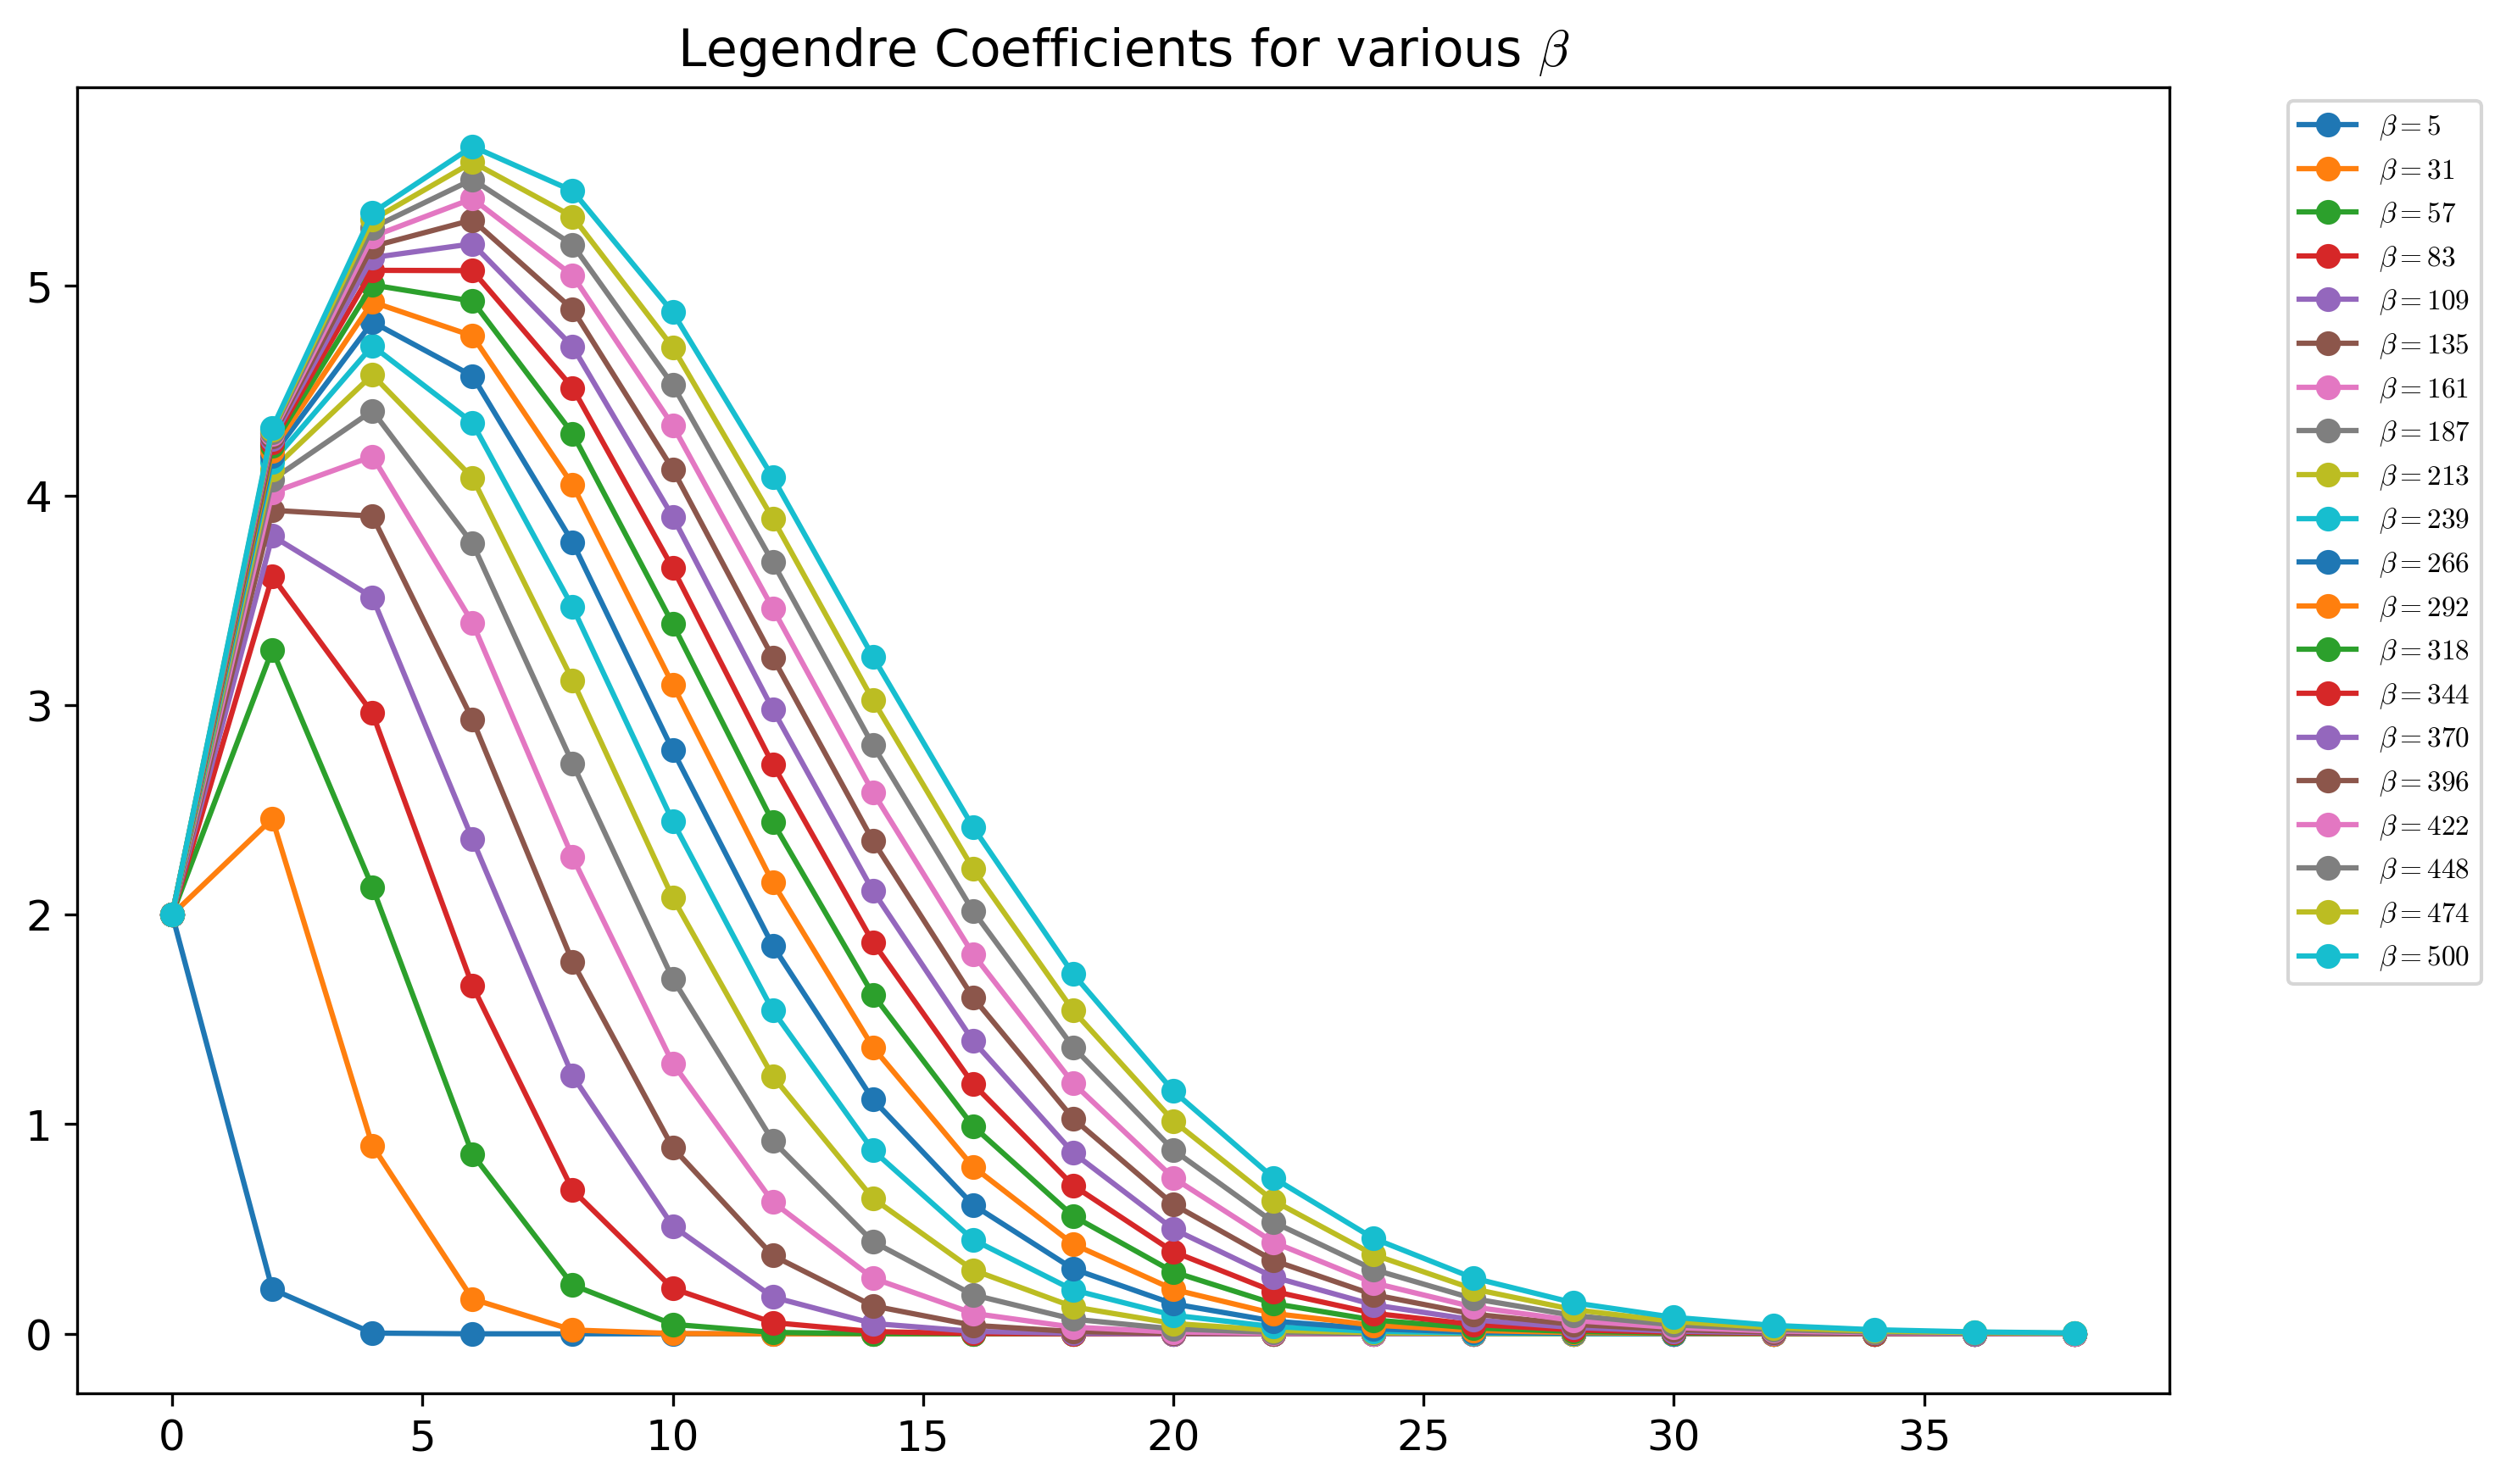

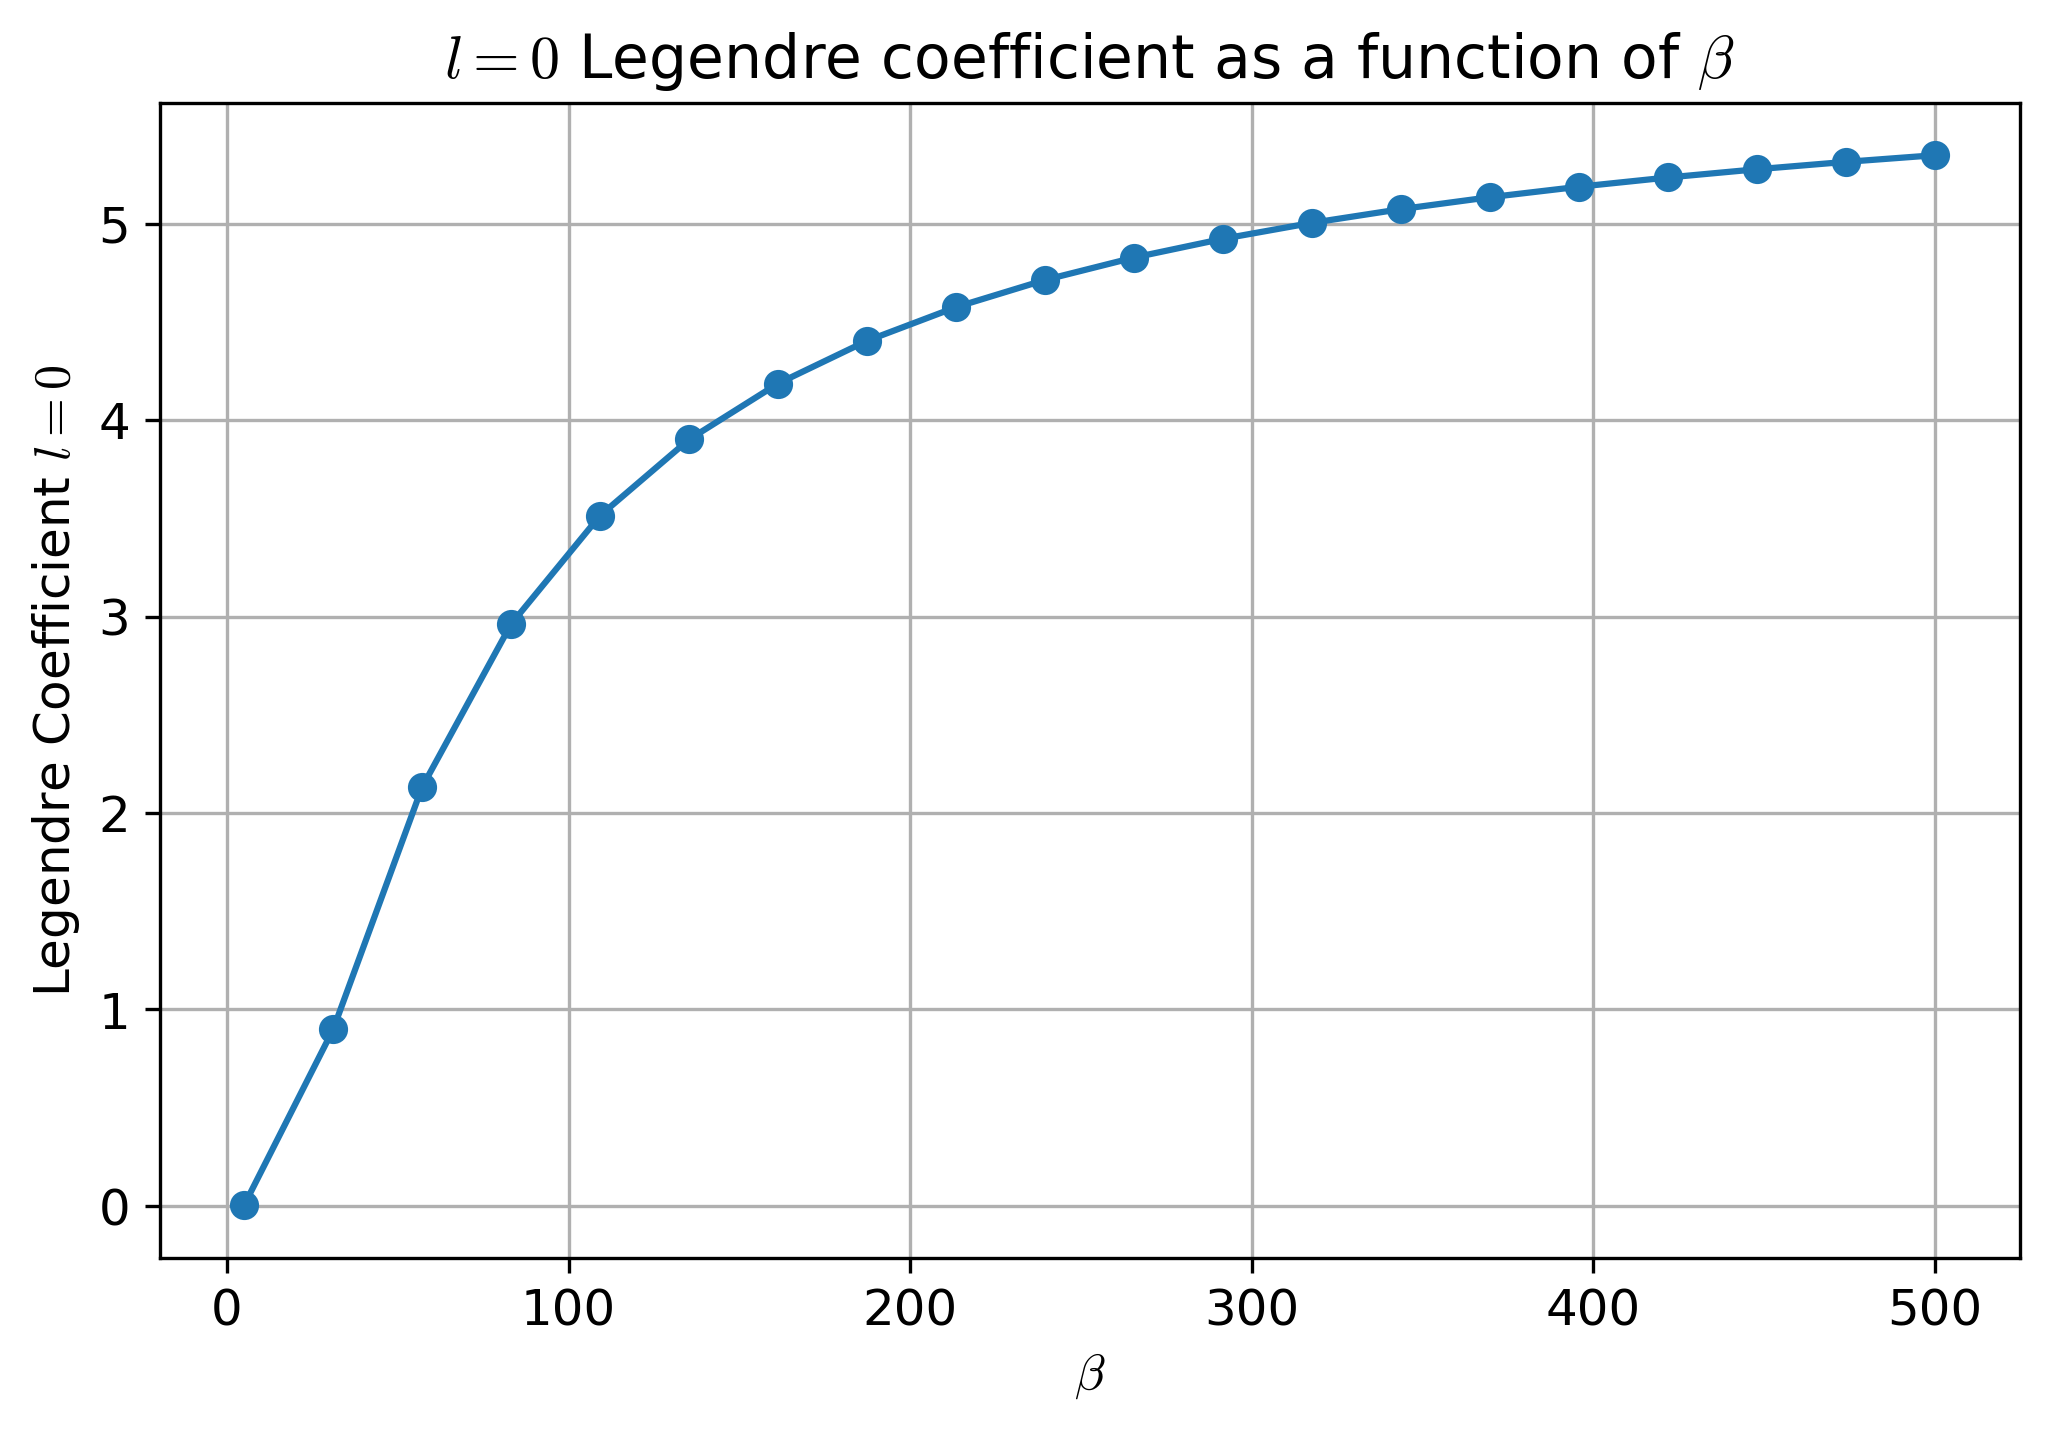

In [23]:
betas = np.linspace(5, 500, 20)
Dleg_dict = {}

# Set up the first plot
plt.figure(figsize=(10, 6))

for b in betas:
    # Setup Green's functions for the current beta
    D_iw = GfImFreq(indices=[0], beta=b, statistic="Boson", n_points=n_tau_bosonic//2)
    d_tau = GfImTime(indices=[0], beta=b, statistic="Boson", n_points=n_tau_bosonic+3)
    
    # Fill with data
    D_iw << Function(lambda w: 2 * g02/wp * wp**2 / (w**2 - wp**2))
    d_tau << Fourier(D_iw)
    
    # Fit and store Legendre polynomial
    Dleg = fit_legendre(d_tau, order=40)
    Dleg_dict[b] = Dleg
    
    # Plot on top of each other
    #oplot(Dleg.real, label=f"$\\beta={b:.0f}$")
    coeffs = Dleg.data[:, 0, 0].real
    
    # Select even indices
    l_indices = np.arange(len(coeffs))
    even_indices = l_indices % 2 == 0
    
    # Plot only the even coefficients with standard matplotlib
    plt.plot(l_indices[even_indices], coeffs[even_indices], marker='o', 
             linestyle='-', label=f"$\\beta={b:.0f}$")


plt.title("Legendre Coefficients for various $\\beta$")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


# Extract the l=0 coefficient for each beta
c0_vals = [Dleg_dict[b].data[4][0][0].real for b in betas]

# Set up the second plot for the l=0 coefficient vs beta
plt.figure(figsize=(8, 5))
plt.plot(betas, c0_vals, '-o')
plt.xlabel(r"$\beta$")
plt.ylabel(r"Legendre Coefficient $l=0$")
plt.title(r"$l=0$ Legendre coefficient as a function of $\beta$")
plt.grid(True)
plt.show()

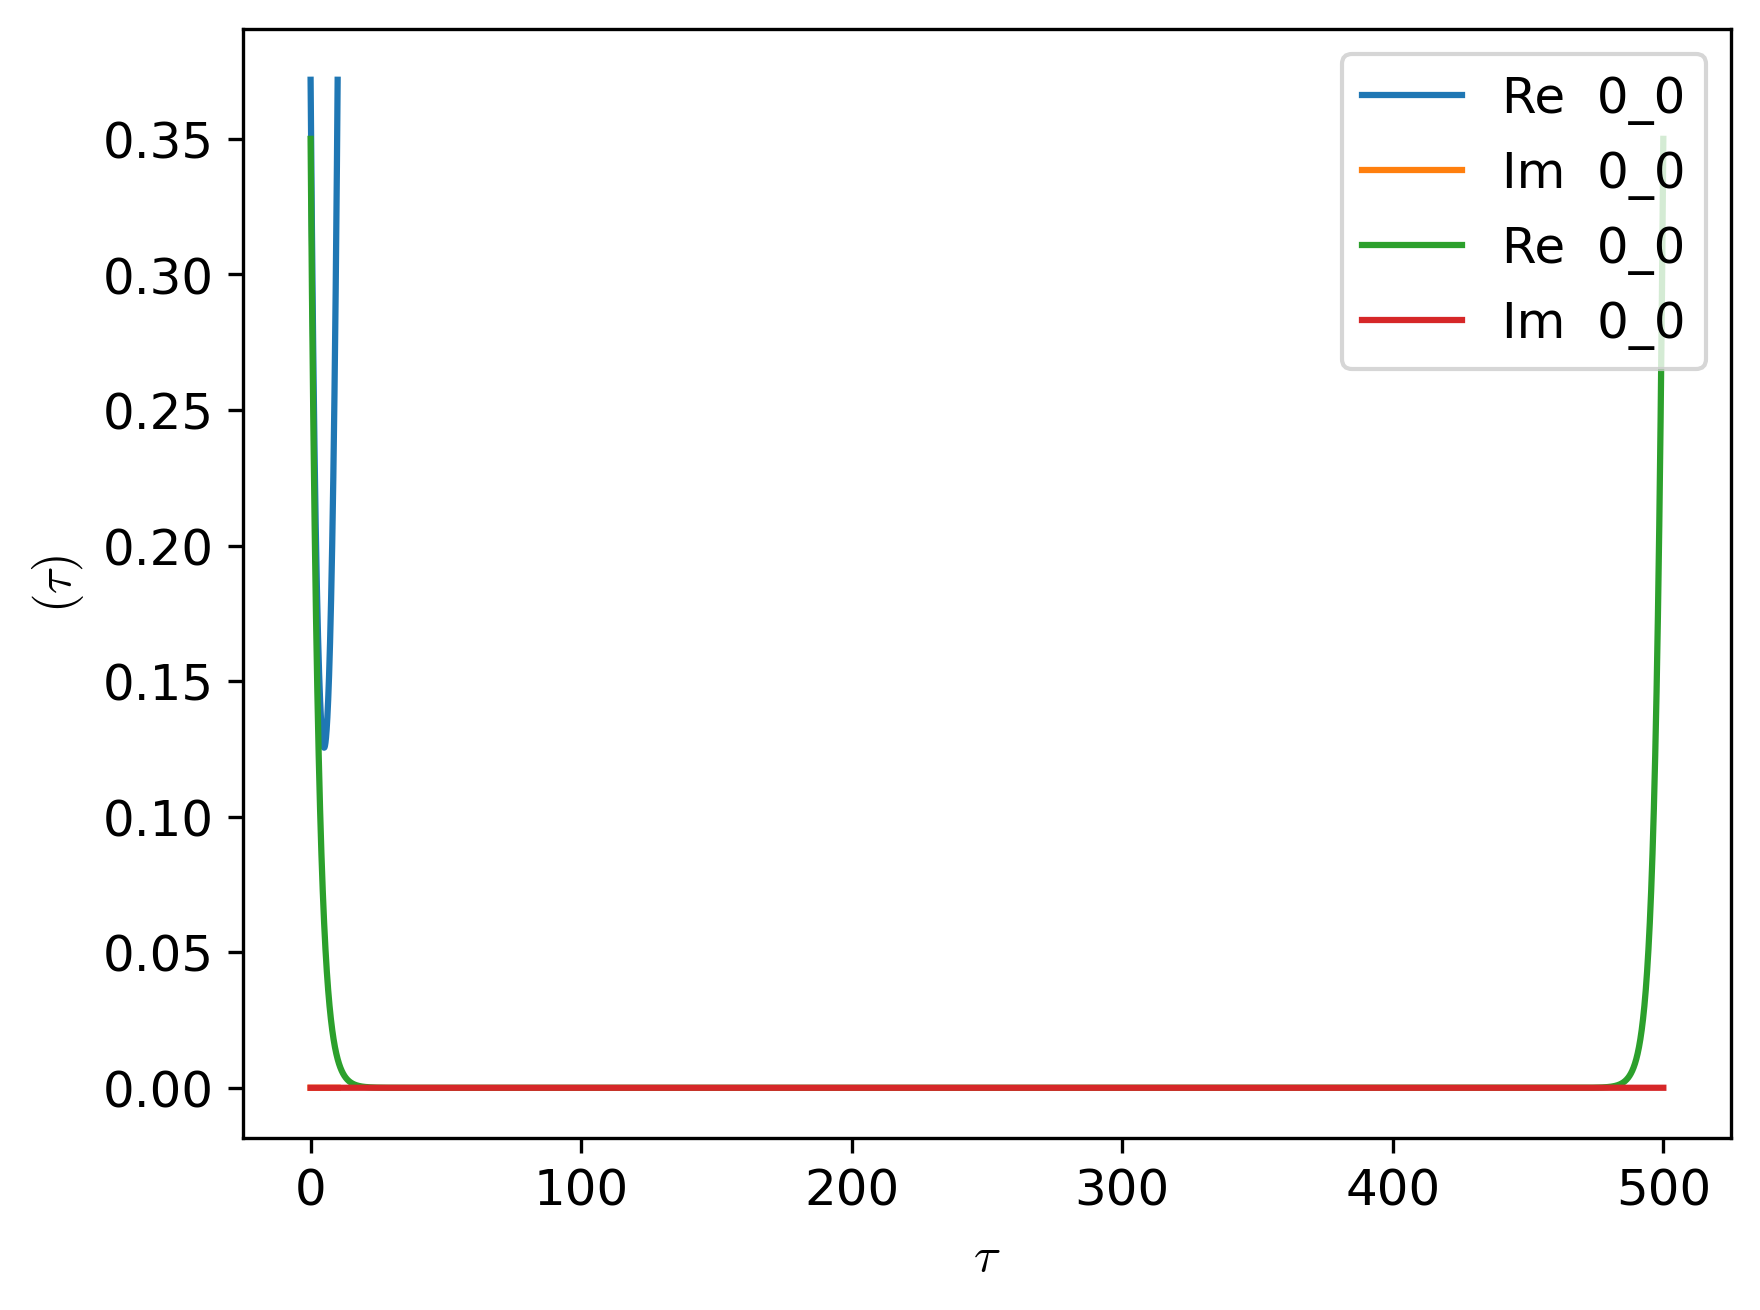

In [24]:
oplot(D_tau_recon)
oplot(d_tau)

plt.show()

In [38]:
G_tau_hyb["up"]

Green's Function G_tau_up with mesh Imaginary time mesh with beta = 10, statistics = Fermion, N = 4096 and target_shape (1, 1): 

['G_tau']
['G0_iw', 'G_iw', 'chiAB_tau']
['G_tau', 'O_tau', 'Sigma_iw', 'average_sign', 'perturbation_order']
1.0 average sign


/home/andrewhardy/Documents/CCQ/coqui_install/lib/python3.12/site-packages/h5/archive.py:232: UserWarning: The hdf5 format Histogram is not recognized. Returning as a group. Did you forgot to import this python class ?
  warnings.warn(f"The hdf5 format {hdf5_format} is not recognized. Returning as a group. Did you forgot to import this python class ?")


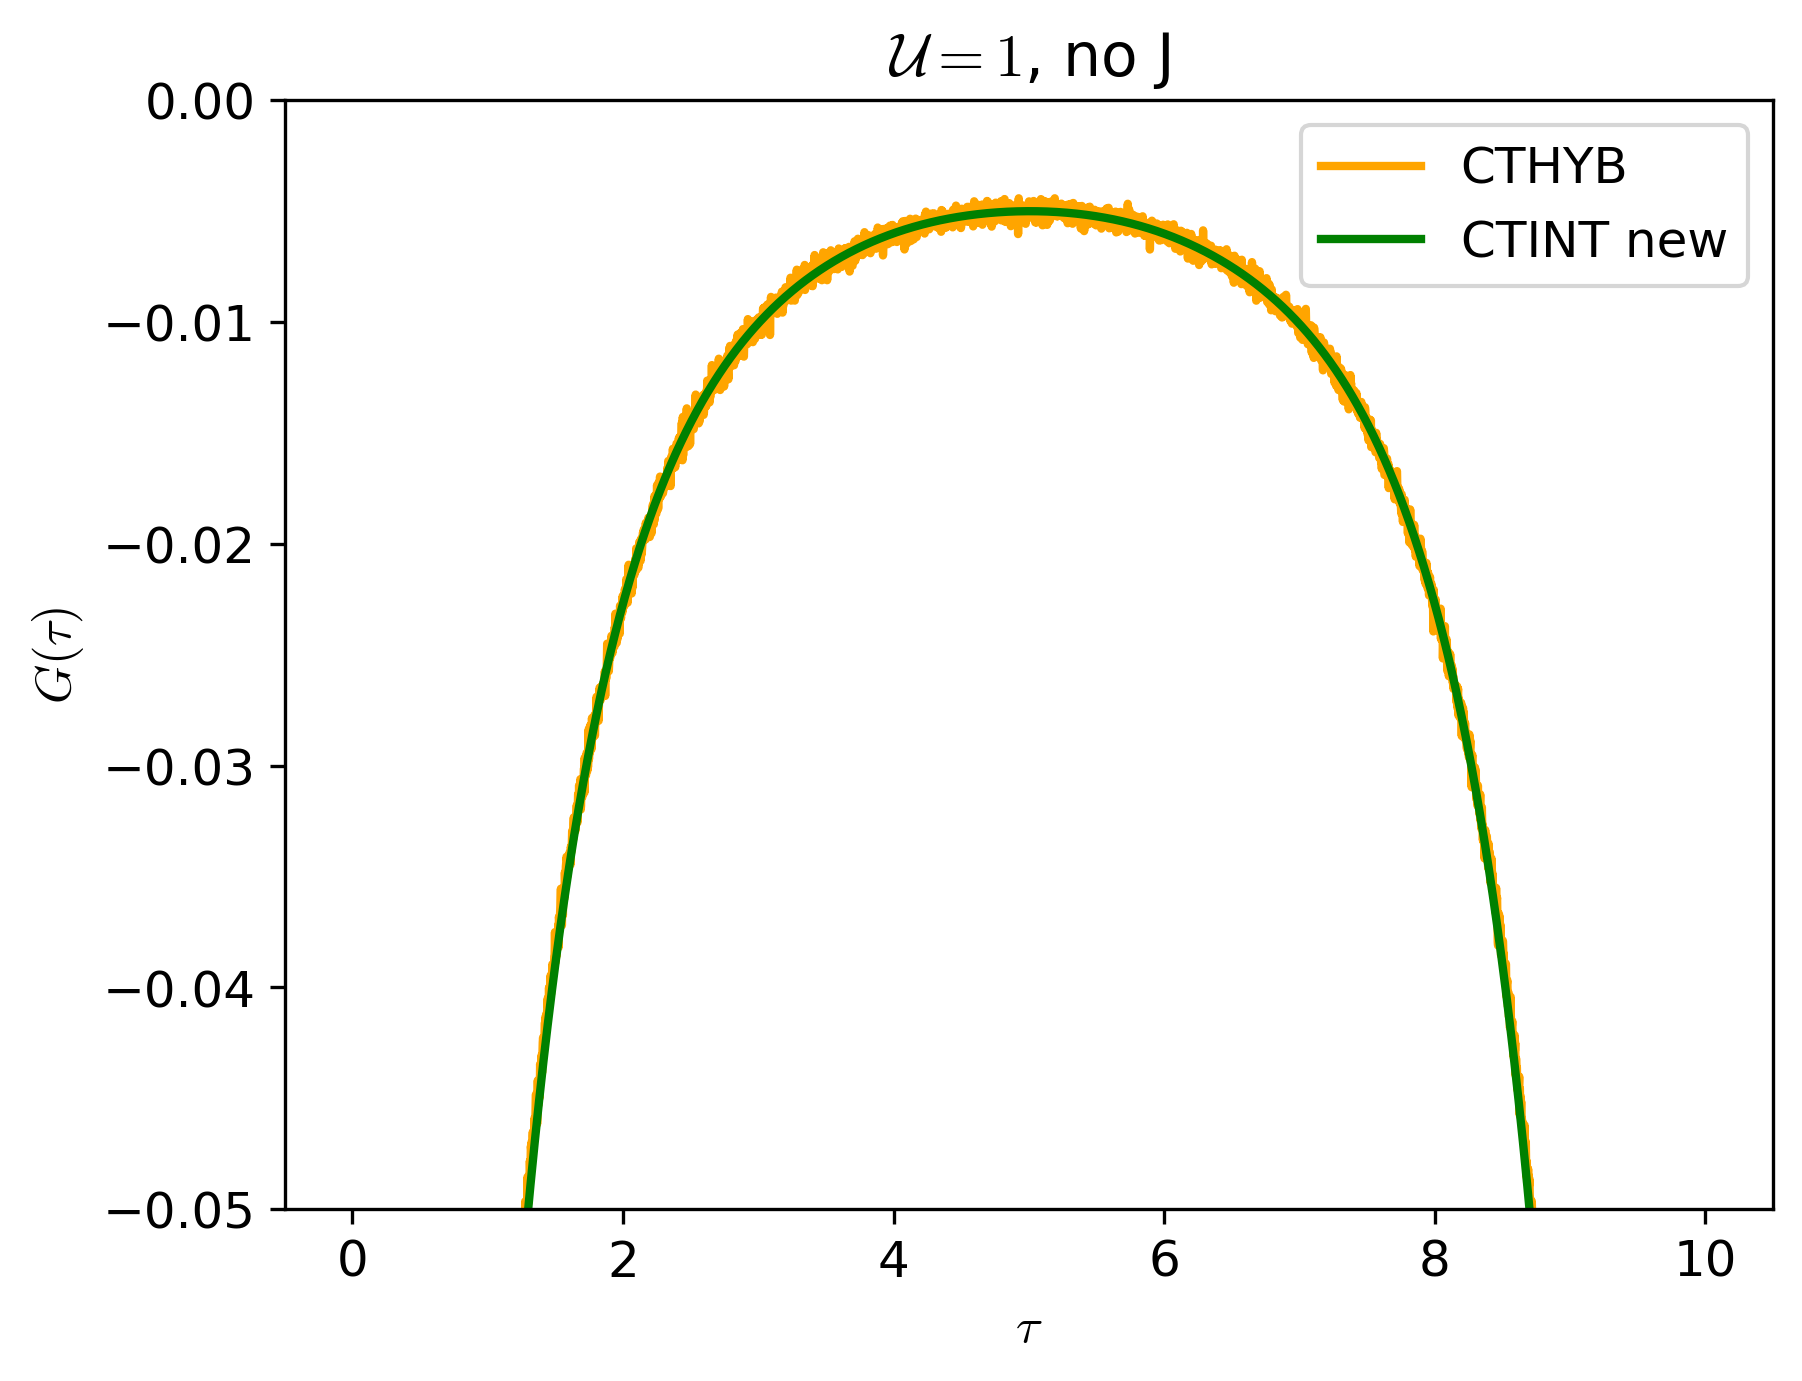

In [39]:
with HDFArchive(f"{data_ref}/ctint.ref.h5", "r") as A:
    G_tau_int_1 = A["dmft_loop/i_001/S/G_tau"]
    q_tau = A["dmft_loop/i_000/Q_tau"]

with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0-U-4.0_0.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_tau_seg = A["G_tau"]
    #nn = A["nn_tau"]
    #nn_iw = A["nn_nu"]
    #nn_nu  = make_gf_dlr_imtime(nn_iw)
    #F_tau = A["F_tau"]
    #Sigma_tau_seg = A["Sigma_tau"]
    #Sigma_iw_seg = A["Sigma_iw"]

with HDFArchive(f"{data_loc}/spin_spin_ctint_J-1.0-U-4.0_0.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_iw_int = A["G_iw"]
    G_tau_int = make_gf_dlr_imtime(G_iw_int)
    G_int_dlr = make_gf_dlr(G_iw_int)
    G_int_tau = make_gf_imtime(G_int_dlr, len(G_tau_seg["up"].data[:,0,0]))
    tau_int = np.array([float(t) for t in G_int_tau.mesh])
    chiAB_tau = A["chiAB_tau"]
    SzSz_int_tau = chiAB_tau#make_gf_dlr_imtime(chiAB_tau)
    #G_int_data = G_int_tau.data[:, 0, 0].real


# with HDFArchive(f"{data_loc}/spin_spin_ctint_old_J-0.5-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
#     print(A.keys())
#     G_iw = A["G_iw"]
#     n_iw = len(G_iw["up"].data)
#     G_tau_int_2 = make_gf_from_fourier(G_iw)
#     nn_ctint = A["chi2ph_tau_from_M3"]
#     nn_ctint_iw = A["chiAB_iw"]
    #nn_ctint = make_gf_from_fourier(nn_ctint_iw)

with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-0.5-U-4.0_0.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000000_mins-70.h5", "r") as A:
#with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-1.0-U-4.0_0.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000000_mins-50.h5", "r") as A:


    print(A.keys())
    G_tau_hyb = A["G_tau"]
    print(A["average_sign"], "average sign")
    x = A["perturbation_order"]
    Sz = A["O_tau"]
    Sigma_iw_hyb = A["Sigma_iw"]

oplot(G_tau_hyb["up"].real, color="orange", linewidth = 2.0, label="CTHYB")
#oplot(G_tau_seg["up"].real, color="blue", linewidth = 2.0, label="CTSEG")
oplot(G_int_tau["up"].real, color="green", linewidth = 2.0, label="CTINT new")
plt.title(r"$\mathcal{U} = 1$, no J")
plt.ylabel(r"$G(\tau)$")
plt.ylim(-0.05, 0.0)
plt.legend()
plt.show()

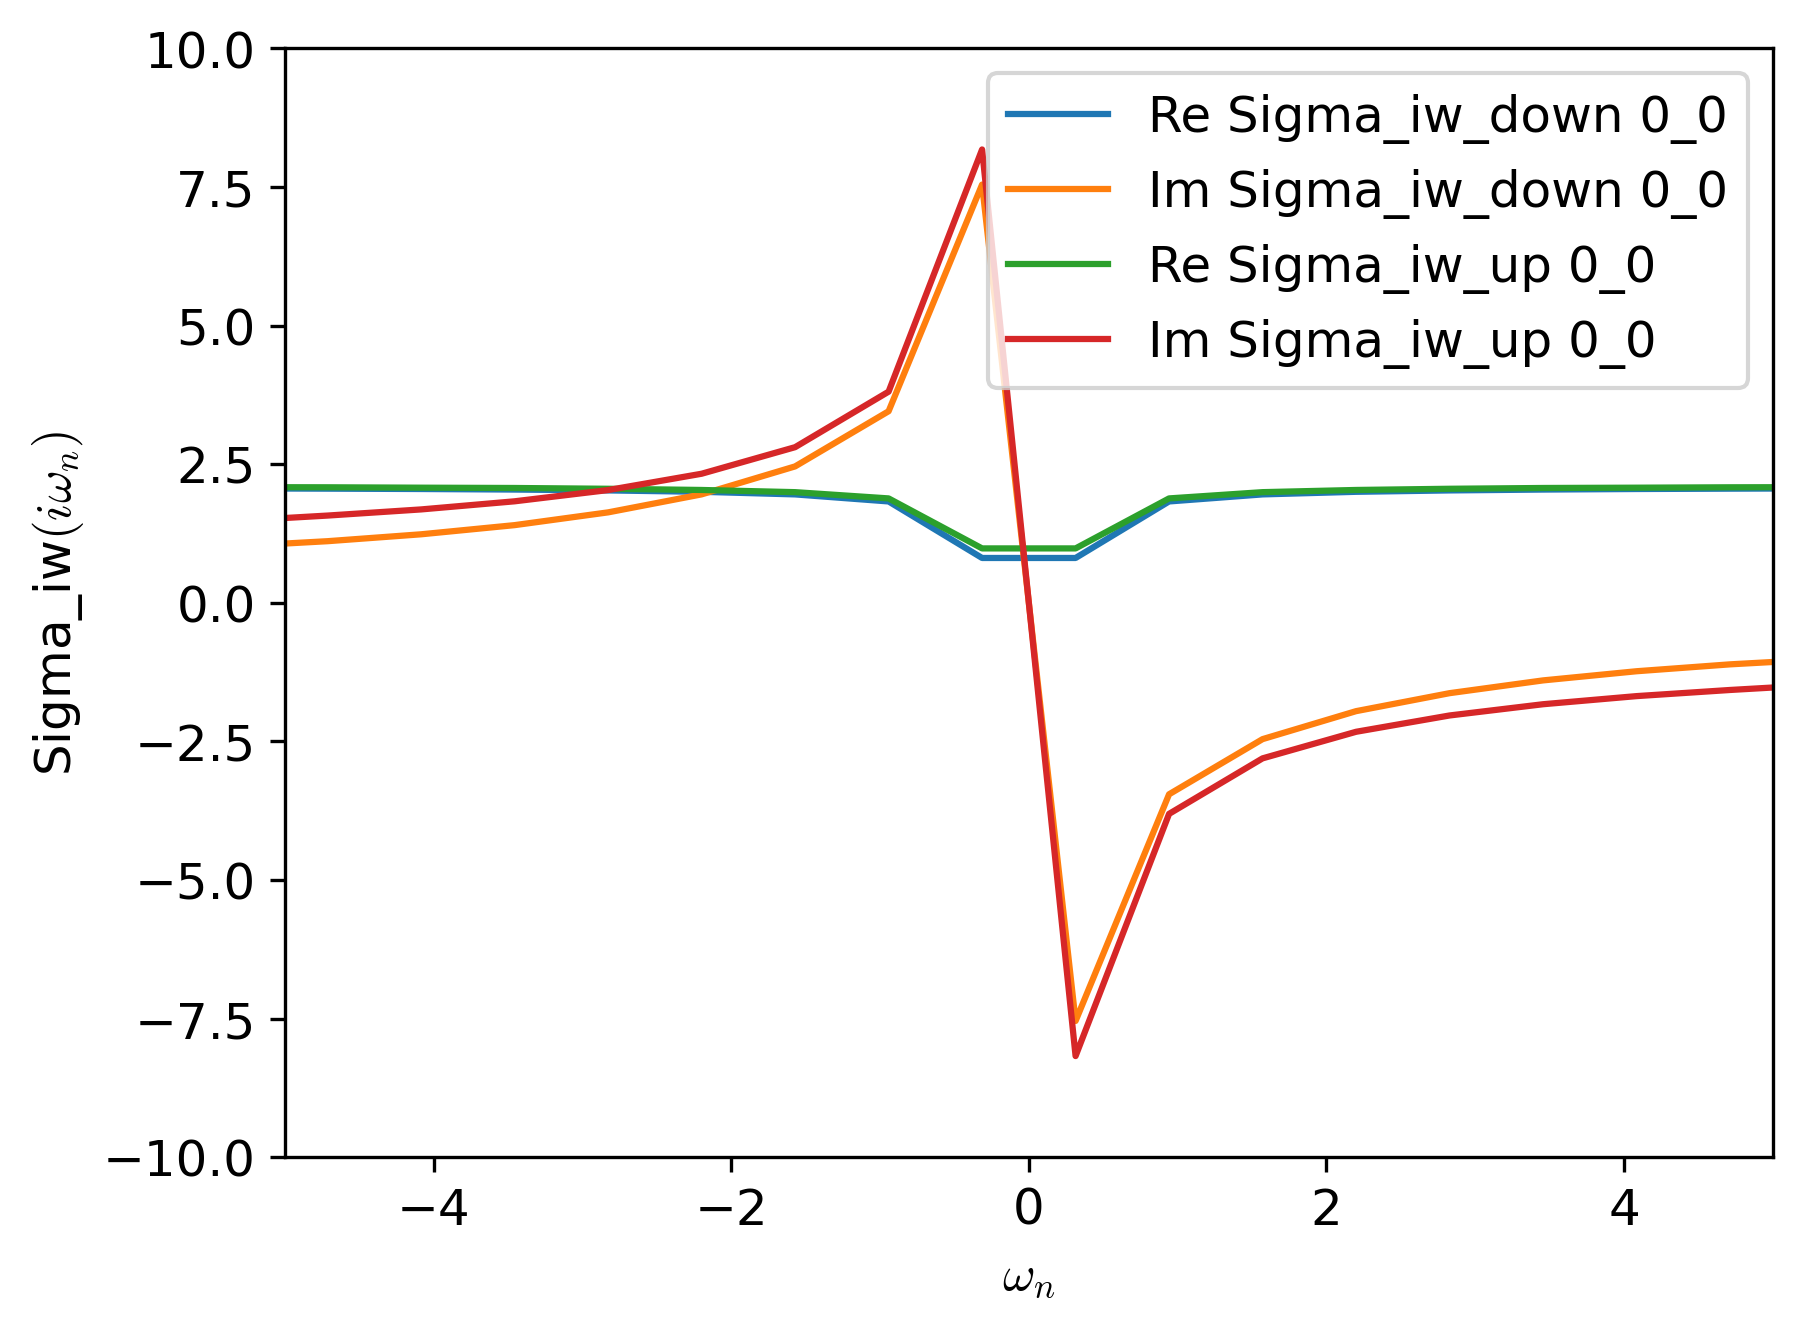

In [26]:
oplot(Sigma_iw_hyb)
plt.xlim(-5,5)
plt.ylim(-10,10)
plt.show()

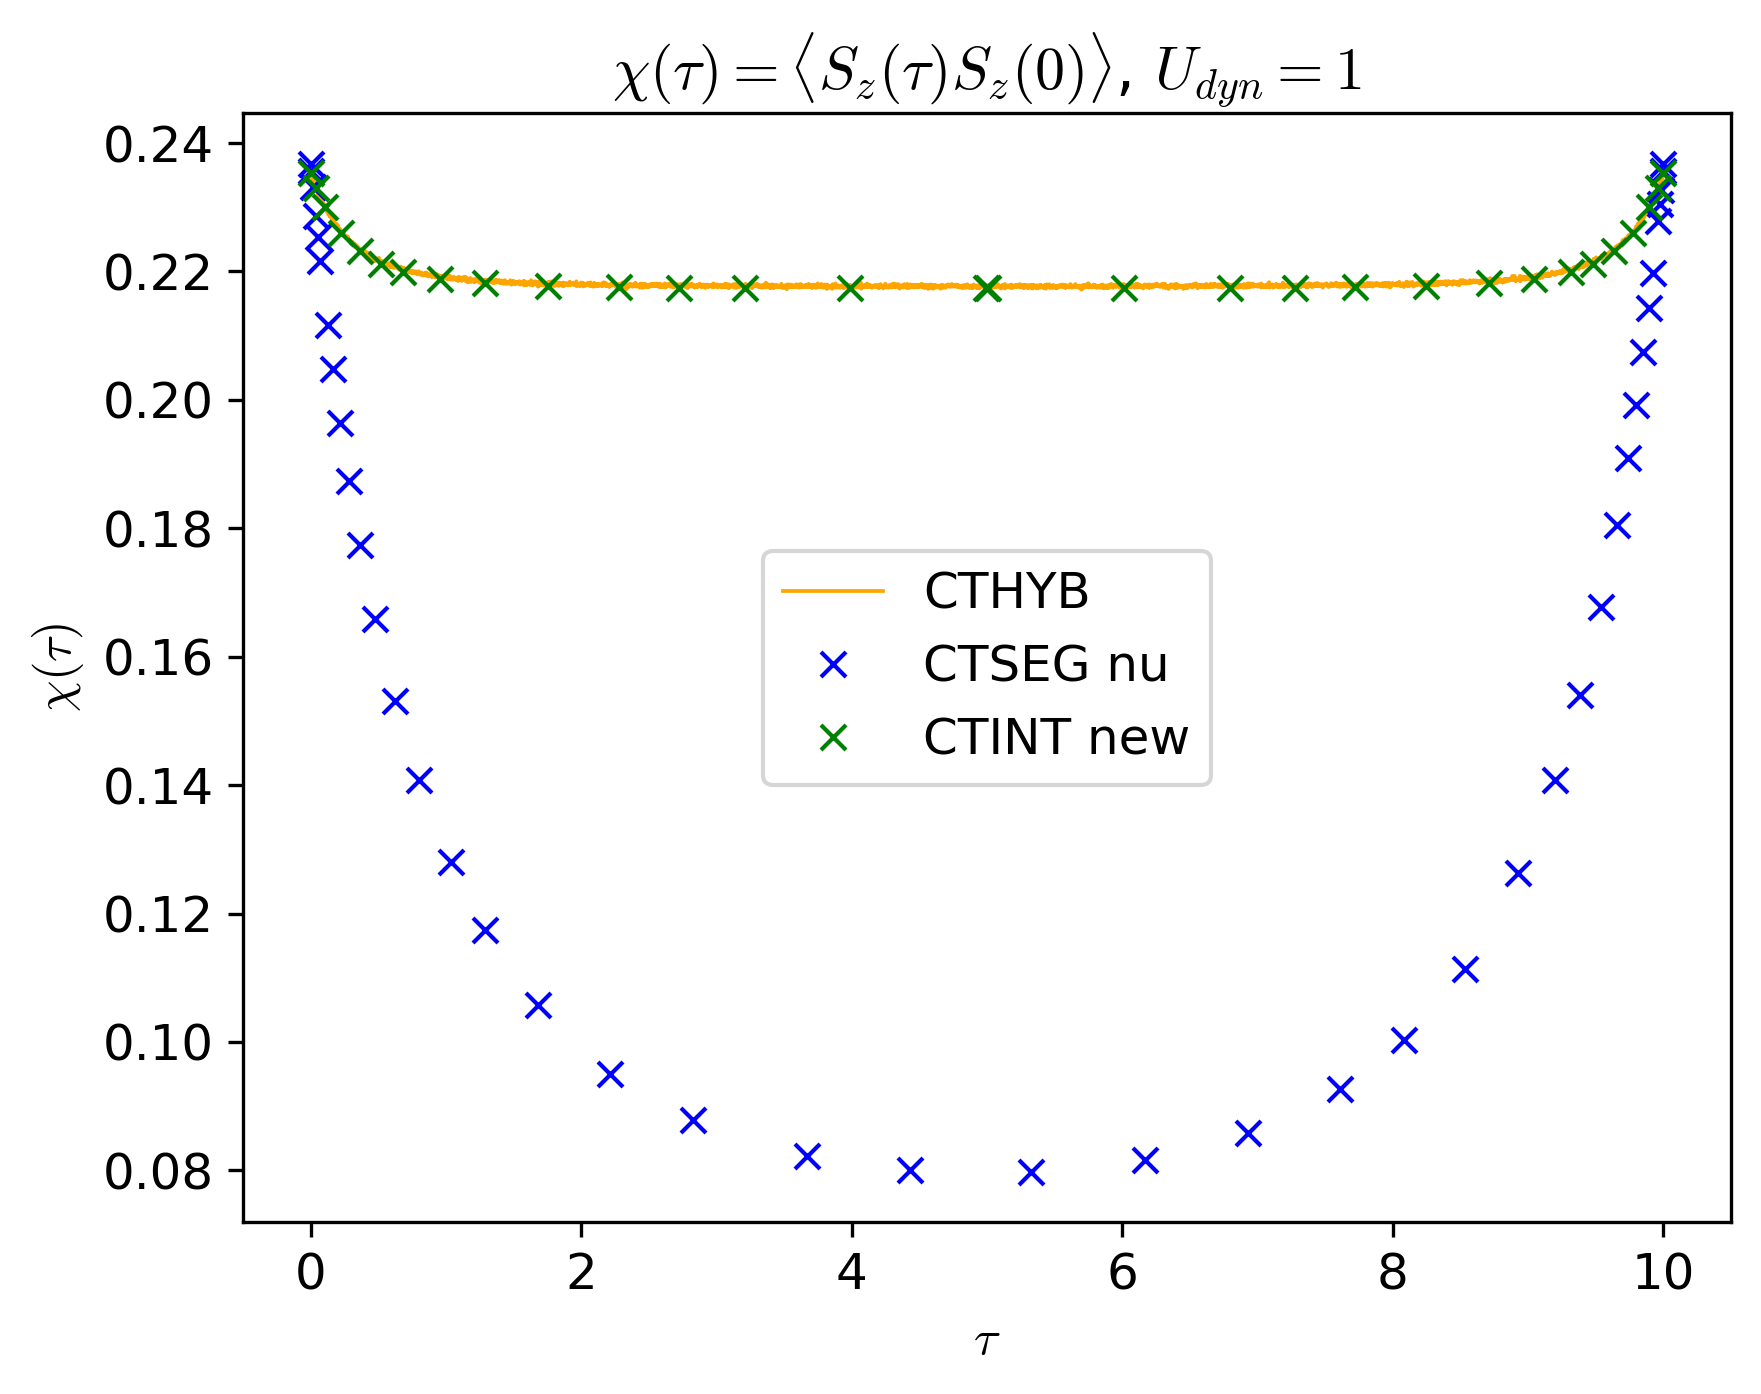

In [ ]:
Sz_ctseg = 0.25*(nn["up", "up"   ] - nn["up", "down"] - nn["down", "up"] +nn["down", "down"])
Sz_nu = 0.25*(nn_nu["up", "up" ] - nn_nu["up", "down"] - nn_nu["down", "up"] +nn_nu["down", "down"])
Sz_ctint = SzSz_int_tau#1.0*(nn_ctint["up", "up" ] - nn_ctint["up", "dn"] - nn_ctint["dn", "up"] +nn_ctint["dn", "dn"])
Sz_ctint_dlr = make_gf_dlr(Sz_ctint)
Sz_ctint = make_gf_dlr_imtime(Sz_ctint_dlr)
oplot(Sz.real, color="orange", linewidth = 0.9, label="CTHYB")
#oplot(Sz_ctseg.real, color="black", linewidth = 0.9, label="CTSEG")
oplot(Sz_nu.real, color="blue", linewidth = 0.9, label="CTSEG nu")
oplot(Sz_ctint.real, color="green", linewidth = 0.9, label="CTINT new")
plt.title(r"$\chi(\tau) =\langle S_z(\tau) S_z(0) \rangle$, $U_{dyn} = 1$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend()
plt.show()

/home/andrewhardy/Documents/CCQ/unstable/installation/lib/python3.12/site-packages/triqs/plot/mpl_interface.py:110: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt_fct(X, Y, *opt_list, **curve_dict)
/home/andrewhardy/Documents/CCQ/unstable/installation/lib/python3.12/site-packages/triqs/plot/mpl_interface.py:110: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  plt_fct(X, Y, *opt_list, **curve_dict)


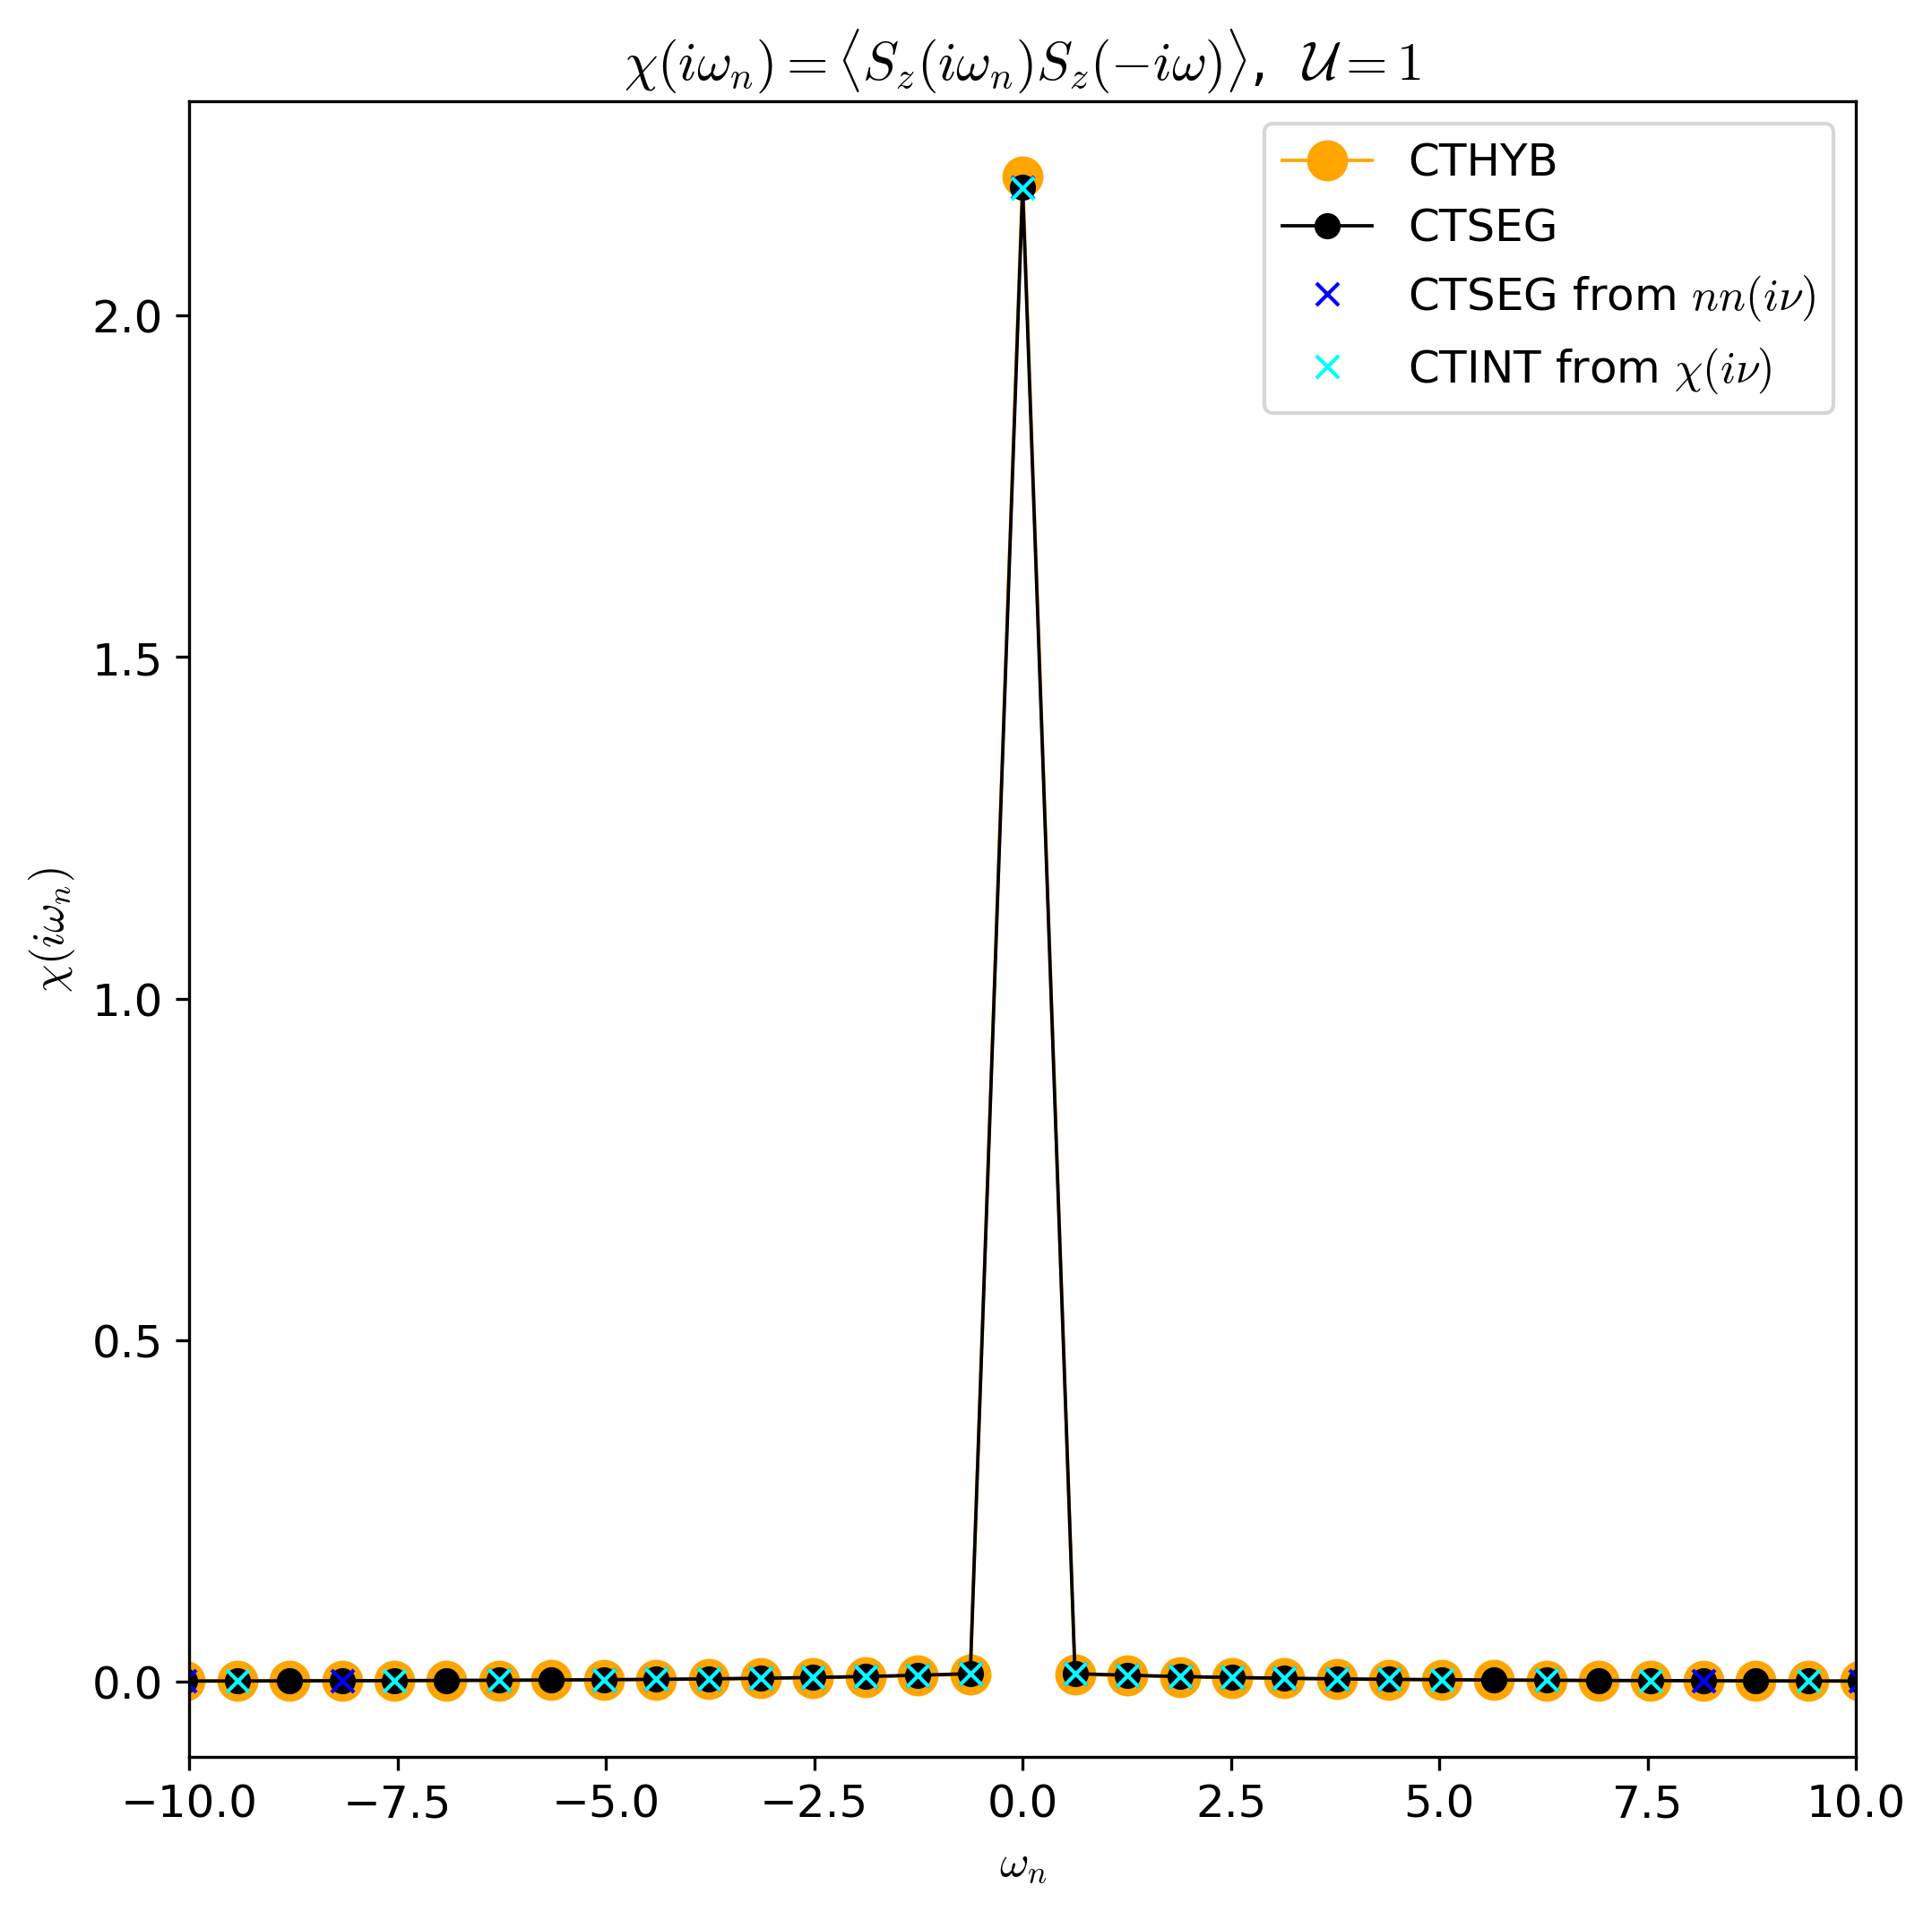

In [28]:
Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_cthyb_fourier = make_gf_from_fourier(Sz)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_nu)
Sz_ctint_fourier = make_gf_dlr_imfreq(Sz_ctint)

plt.figure(figsize=(8,8))
plt.xlim(-10,10)
oplot(Sz_cthyb_fourier.real, "-o",color="orange", markersize = 10, linewidth = 0.9, label="CTHYB")
oplot(Sz_ctseg_fourier.real, "-o",color="black",  linewidth = 0.9, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-o",color="blue",  linewidth = 0.9, label="CTSEG from $nn(i\\nu)$")
oplot(Sz_ctint_fourier.real, "-o",color="cyan",  linewidth = 0.9, label="CTINT from $\\chi(i\\nu)$")
plt.title(r"$\chi(i\omega_n) =\langle S_z(i\omega_n) S_z(-i\omega) \rangle$,  $\mathcal{U} = 1$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend()
plt.show()

### CTSEG compared to CTHYB with full dynamical interactions

['G_tau', 'average_sign', 'densities', 'nn', 'nn_nu', 'nn_tau', 'perturbation_order_D', 'perturbation_order_J']
['G0_iw', 'G_iw', 'chiAB_tau']
['G_tau', 'O_tau', 'average_sign', 'perturbation_order']
0.29949835766666666 average sign


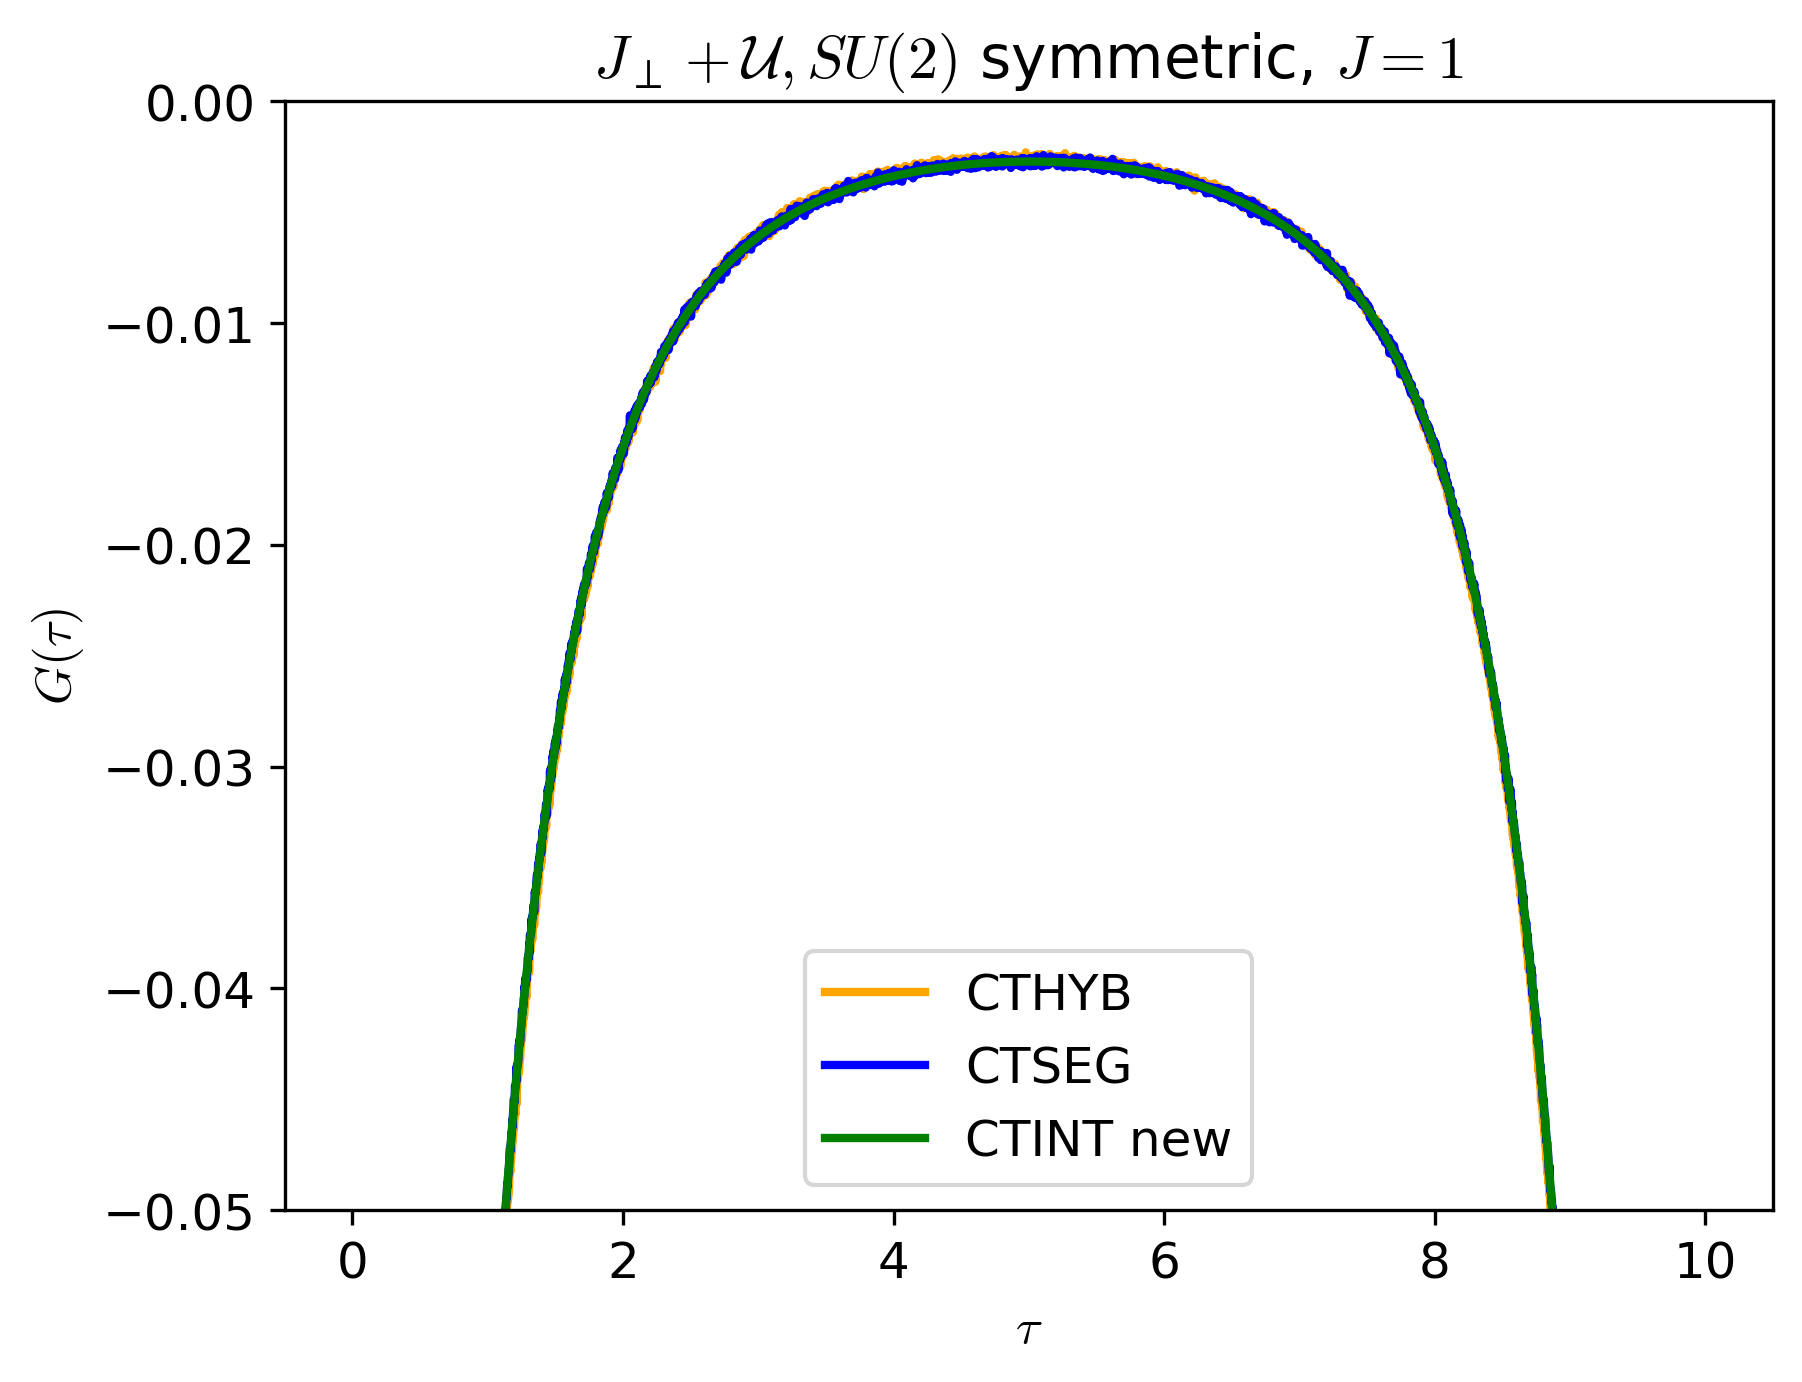

In [29]:
with HDFArchive(f"{data_ref}/ctint.ref.h5", "r") as A:
    G_tau_int_1 = A["dmft_loop/i_001/S/G_tau"]
with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_tau_seg = A["G_tau"]
    nn = A["nn_tau"]
    nn_iw = A["nn_nu"]
    nn_nu  = make_gf_dlr_imtime(nn_iw)

with HDFArchive(f"{data_loc}/spin_spin_ctint_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_iw_int = A["G_iw"]
    G_tau_int = make_gf_dlr_imtime(G_iw_int)
    G_int_dlr = make_gf_dlr(G_iw_int)
    G_int_tau = make_gf_imtime(G_int_dlr, len(G_tau_seg["up"].data[:,0,0]))
    tau_int = np.array([float(t) for t in G_int_tau.mesh])
    chiAB_tau = A["chiAB_tau"]
    SzSz_int_tau = chiAB_tau#make_gf_dlr_imtime(chiAB_tau)
    #G_int_data = G_int_tau.data[:, 0, 0].real


# with HDFArchive(f"{data_loc}/spin_spin_ctint_old_J-0.5-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
#     print(A.keys())
#     G_iw = A["G_iw"]
#     n_iw = len(G_iw["up"].data)
#     G_tau_int_2 = make_gf_from_fourier(G_iw)
#     nn_ctint = A["chi2ph_tau_from_M3"]
#     nn_ctint_iw = A["chiAB_iw"]
    #nn_ctint = make_gf_from_fourier(nn_ctint_iw)

with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000000_mins-250.h5", "r") as A:
    print(A.keys())
    G_tau_hyb = A["G_tau"]
    print(A["average_sign"], "average sign")
    x = A["perturbation_order"]
    Sz = A["O_tau"]

oplot(G_tau_hyb["up"].real, color="orange", linewidth = 2.0, label="CTHYB")
oplot(G_tau_seg["up"].real, color="blue", linewidth = 2.0, label="CTSEG")
oplot(G_int_tau["up"].real, color="green", linewidth = 2.0, label="CTINT new")
plt.title(r"$J_\perp + \mathcal{U}, SU(2)$ symmetric, $J = 1$")
plt.ylabel(r"$G(\tau)$")
plt.ylim(-0.05, 0.0)
plt.legend()
plt.show()

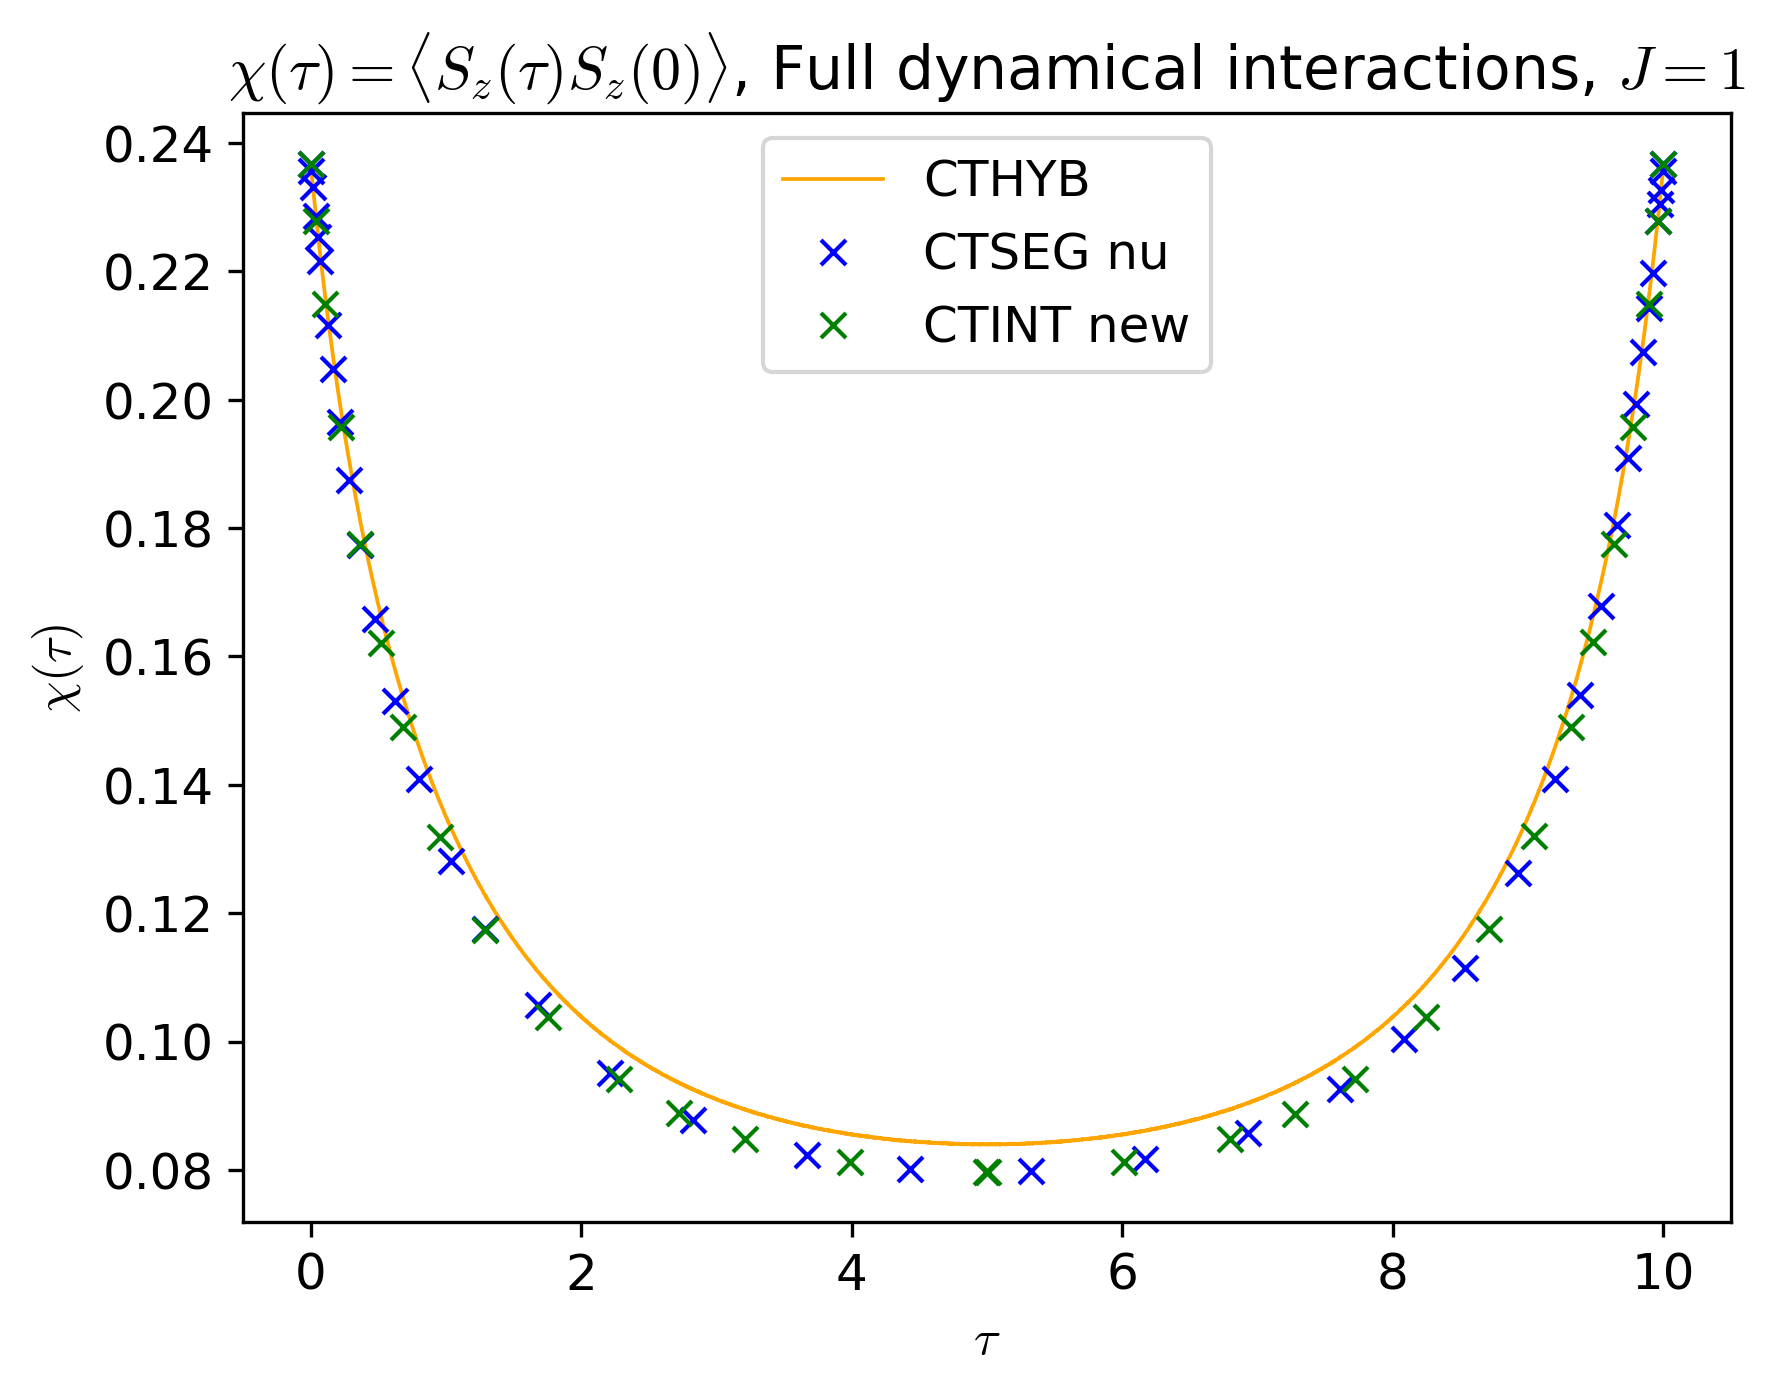

In [30]:
Sz_ctseg = 0.25*(nn["up", "up"   ] - nn["up", "down"] - nn["down", "up"] +nn["down", "down"])
Sz_nu = 0.25*(nn_nu["up", "up" ] - nn_nu["up", "down"] - nn_nu["down", "up"] +nn_nu["down", "down"])
Sz_ctint = SzSz_int_tau#1.0*(nn_ctint["up", "up" ] - nn_ctint["up", "dn"] - nn_ctint["dn", "up"] +nn_ctint["dn", "dn"])
Sz_ctint_dlr = make_gf_dlr(Sz_ctint)
Sz_ctint = make_gf_dlr_imtime(Sz_ctint_dlr)
oplot(Sz.real, color="orange", linewidth = 0.9, label="CTHYB")
#oplot(Sz_ctseg.real, color="black", linewidth = 0.9, label="CTSEG")
oplot(Sz_nu.real, color="blue", linewidth = 0.9, label="CTSEG nu")
oplot(Sz_ctint.real, color="green", linewidth = 0.9, label="CTINT new")
plt.title(r"$\chi(\tau) =\langle S_z(\tau) S_z(0) \rangle$, Full dynamical interactions, $J = 1$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend()
plt.show()

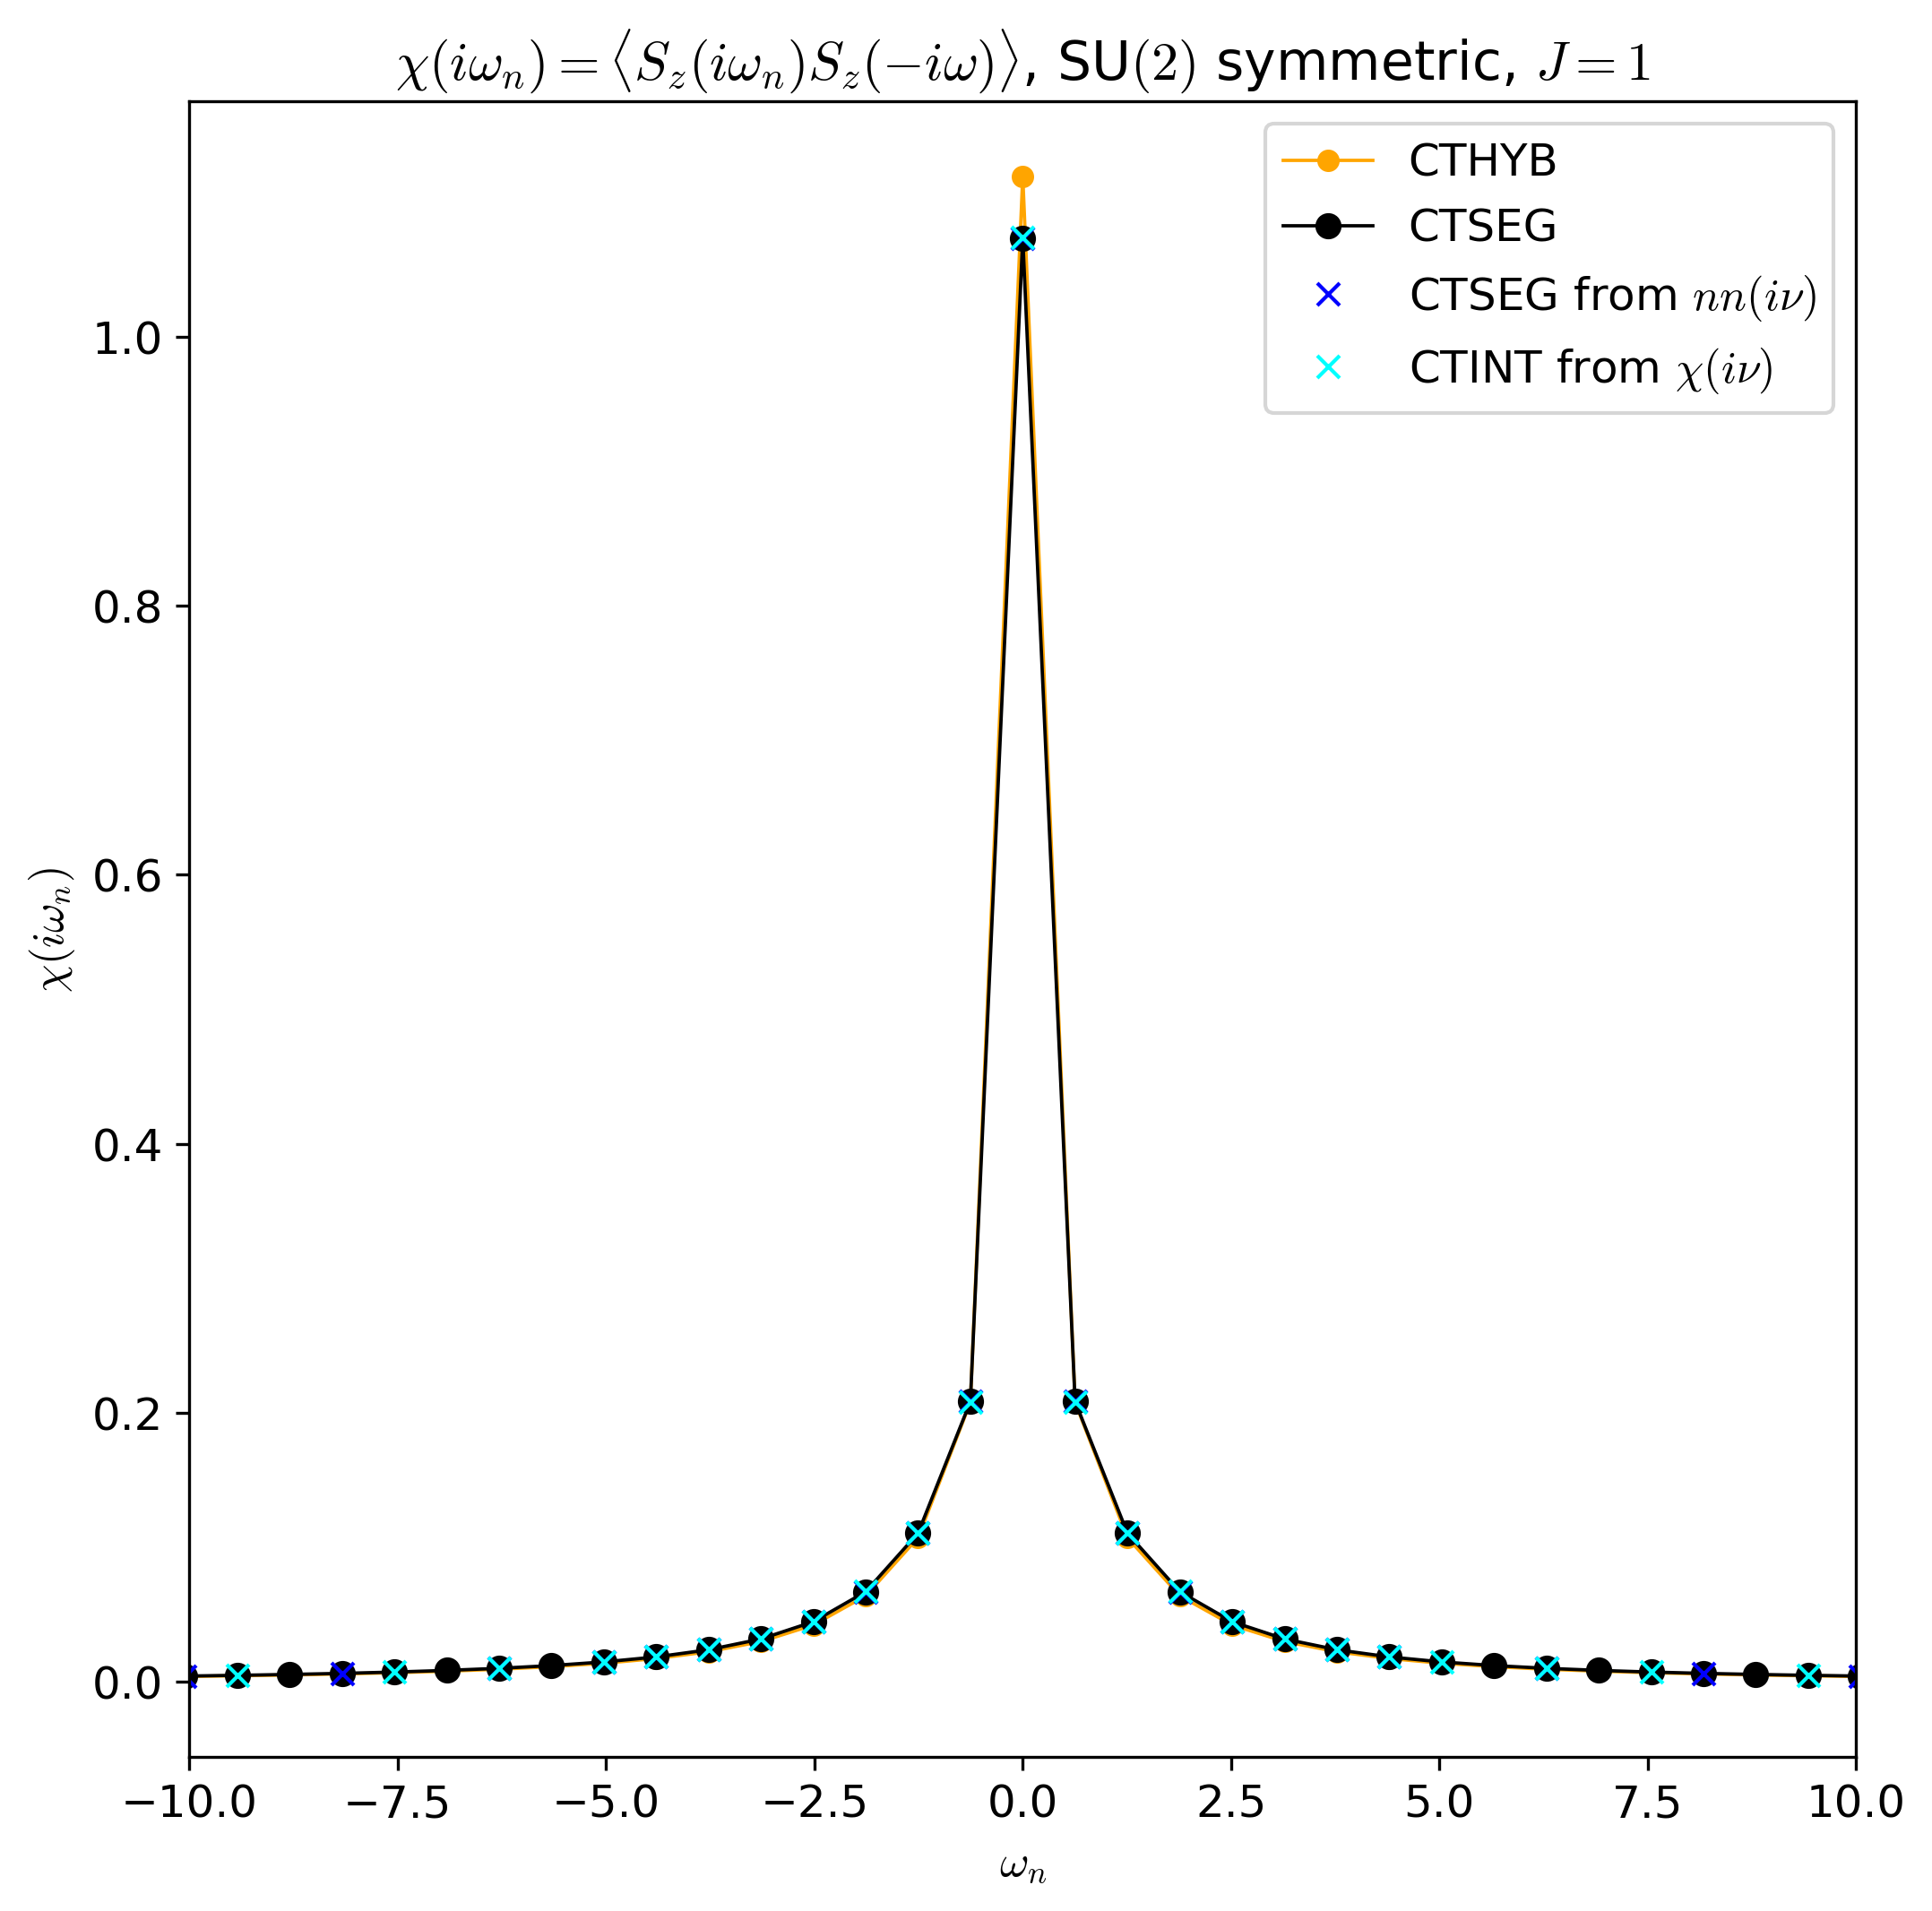

In [31]:
Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_cthyb_fourier = make_gf_from_fourier(Sz)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_nu)
Sz_ctint_fourier = make_gf_dlr_imfreq(Sz_ctint)

plt.figure(figsize=(8,8))
plt.xlim(-10,10)
oplot(Sz_cthyb_fourier.real, "-o",color="orange", markersize = 5, linewidth = 0.9, label="CTHYB")
oplot(Sz_ctseg_fourier.real, "-o",color="black",  linewidth = 0.9, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-o",color="blue",  linewidth = 0.9, label="CTSEG from $nn(i\\nu)$")
oplot(Sz_ctint_fourier.real, "-o",color="cyan",  linewidth = 0.9, label="CTINT from $\\chi(i\\nu)$")
plt.title(r"$\chi(i\omega_n) =\langle S_z(i\omega_n) S_z(-i\omega) \rangle$, SU$(2)$ symmetric, $J = 1$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend()
plt.show()

### CTSEG compared to CTHYB with only J

['G_tau']
['G0_iw', 'G_iw', 'chiAB_tau']
['G_tau', 'O_tau', 'Sigma_iw', 'average_sign', 'perturbation_order']
1.0 average sign


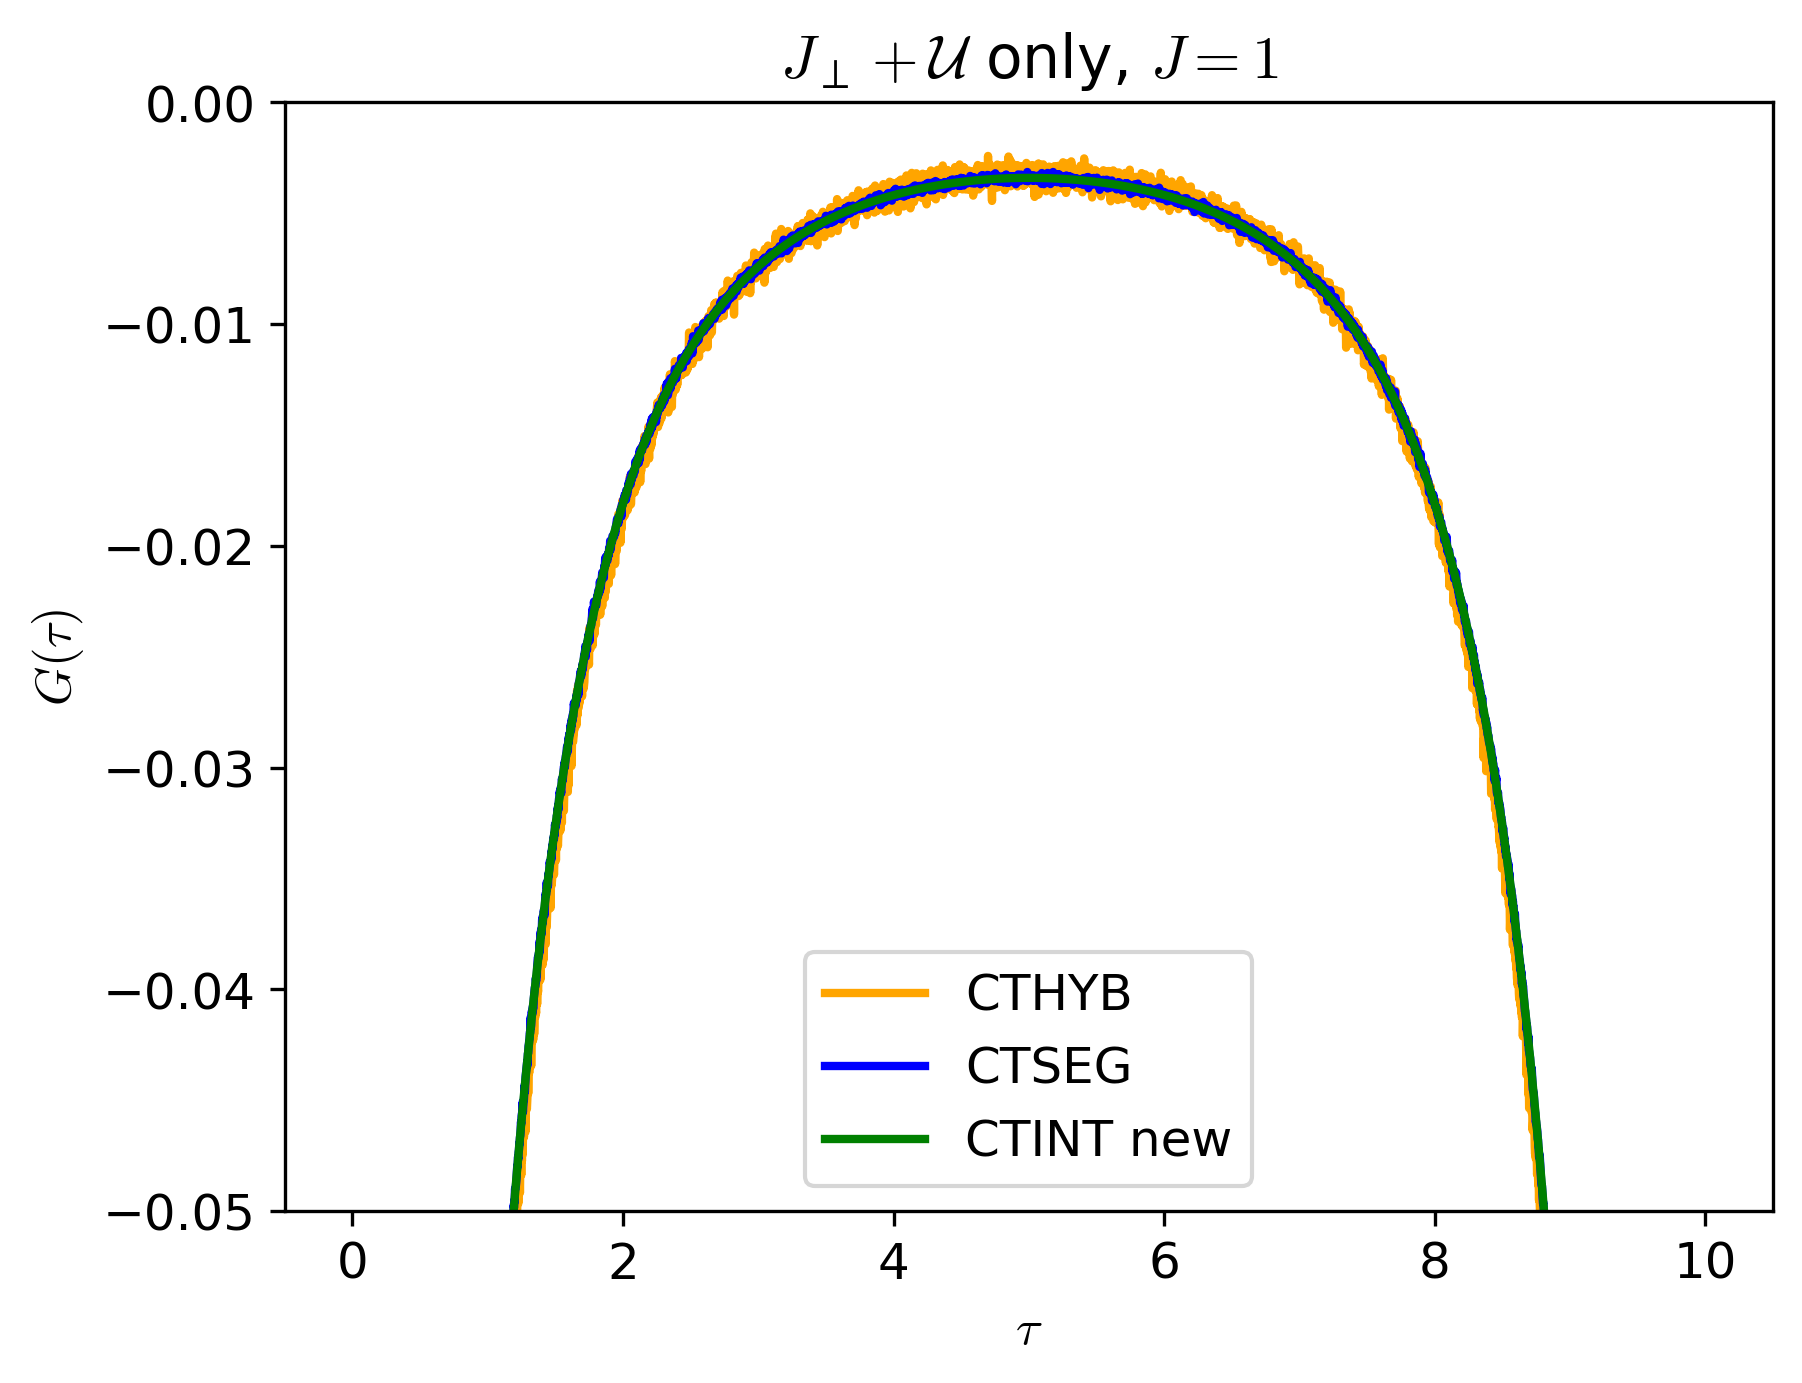

In [32]:
with HDFArchive(f"{data_ref}/ctint.ref.h5", "r") as A:
    G_tau_int_1 = A["dmft_loop/i_001/S/G_tau"]
with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0-U-4.0_1.0_0.0_0.0_0.0_0.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_tau_seg = A["G_tau"]
    #nn = A["nn_tau"]
    #nn_iw = A["nn_nu"]
    nn_nu  = make_gf_dlr_imtime(nn_iw)

with HDFArchive(f"{data_loc}/spin_spin_ctint_J-1.0-U-4.0_1.0_0.0_0.0_0.0_0.0_b-10.0.h5", "r") as A:
    print(A.keys())
    G_iw_int = A["G_iw"]
    G_tau_int = make_gf_dlr_imtime(G_iw_int)
    G_int_dlr = make_gf_dlr(G_iw_int)
    G_int_tau = make_gf_imtime(G_int_dlr, len(G_tau_seg["up"].data[:,0,0]))
    tau_int = np.array([float(t) for t in G_int_tau.mesh])
    chiAB_tau = A["chiAB_tau"]
    SzSz_int_tau = chiAB_tau#make_gf_dlr_imtime(chiAB_tau)
    #G_int_data = G_int_tau.data[:, 0, 0].real


# with HDFArchive(f"{data_loc}/spin_spin_ctint_old_J-0.5-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
#     print(A.keys())
#     G_iw = A["G_iw"]
#     n_iw = len(G_iw["up"].data)
#     G_tau_int_2 = make_gf_from_fourier(G_iw)
#     nn_ctint = A["chi2ph_tau_from_M3"]
#     nn_ctint_iw = A["chiAB_iw"]
    #nn_ctint = make_gf_from_fourier(nn_ctint_iw)

with HDFArchive(f"{data_loc}/spin_spin_cthyb_J-1.0-U-4.0_1.0_0.0_0.0_0.0_0.0_b-10.0_nw-1000000_mins-70.h5", "r") as A:
    print(A.keys())
    G_tau_hyb = A["G_tau"]
    print(A["average_sign"], "average sign")
    x = A["perturbation_order"]
    Sz = A["O_tau"]

oplot(G_tau_hyb["up"].real, color="orange", linewidth = 2.0, label="CTHYB")
oplot(G_tau_seg["up"].real, color="blue", linewidth = 2.0, label="CTSEG")
oplot(G_int_tau["up"].real, color="green", linewidth = 2.0, label="CTINT new")
plt.title(r"$J_\perp + \mathcal{U}$ only, $J = 1$")
plt.ylabel(r"$G(\tau)$")
plt.ylim(-0.05, 0.0)
plt.legend()
plt.show()

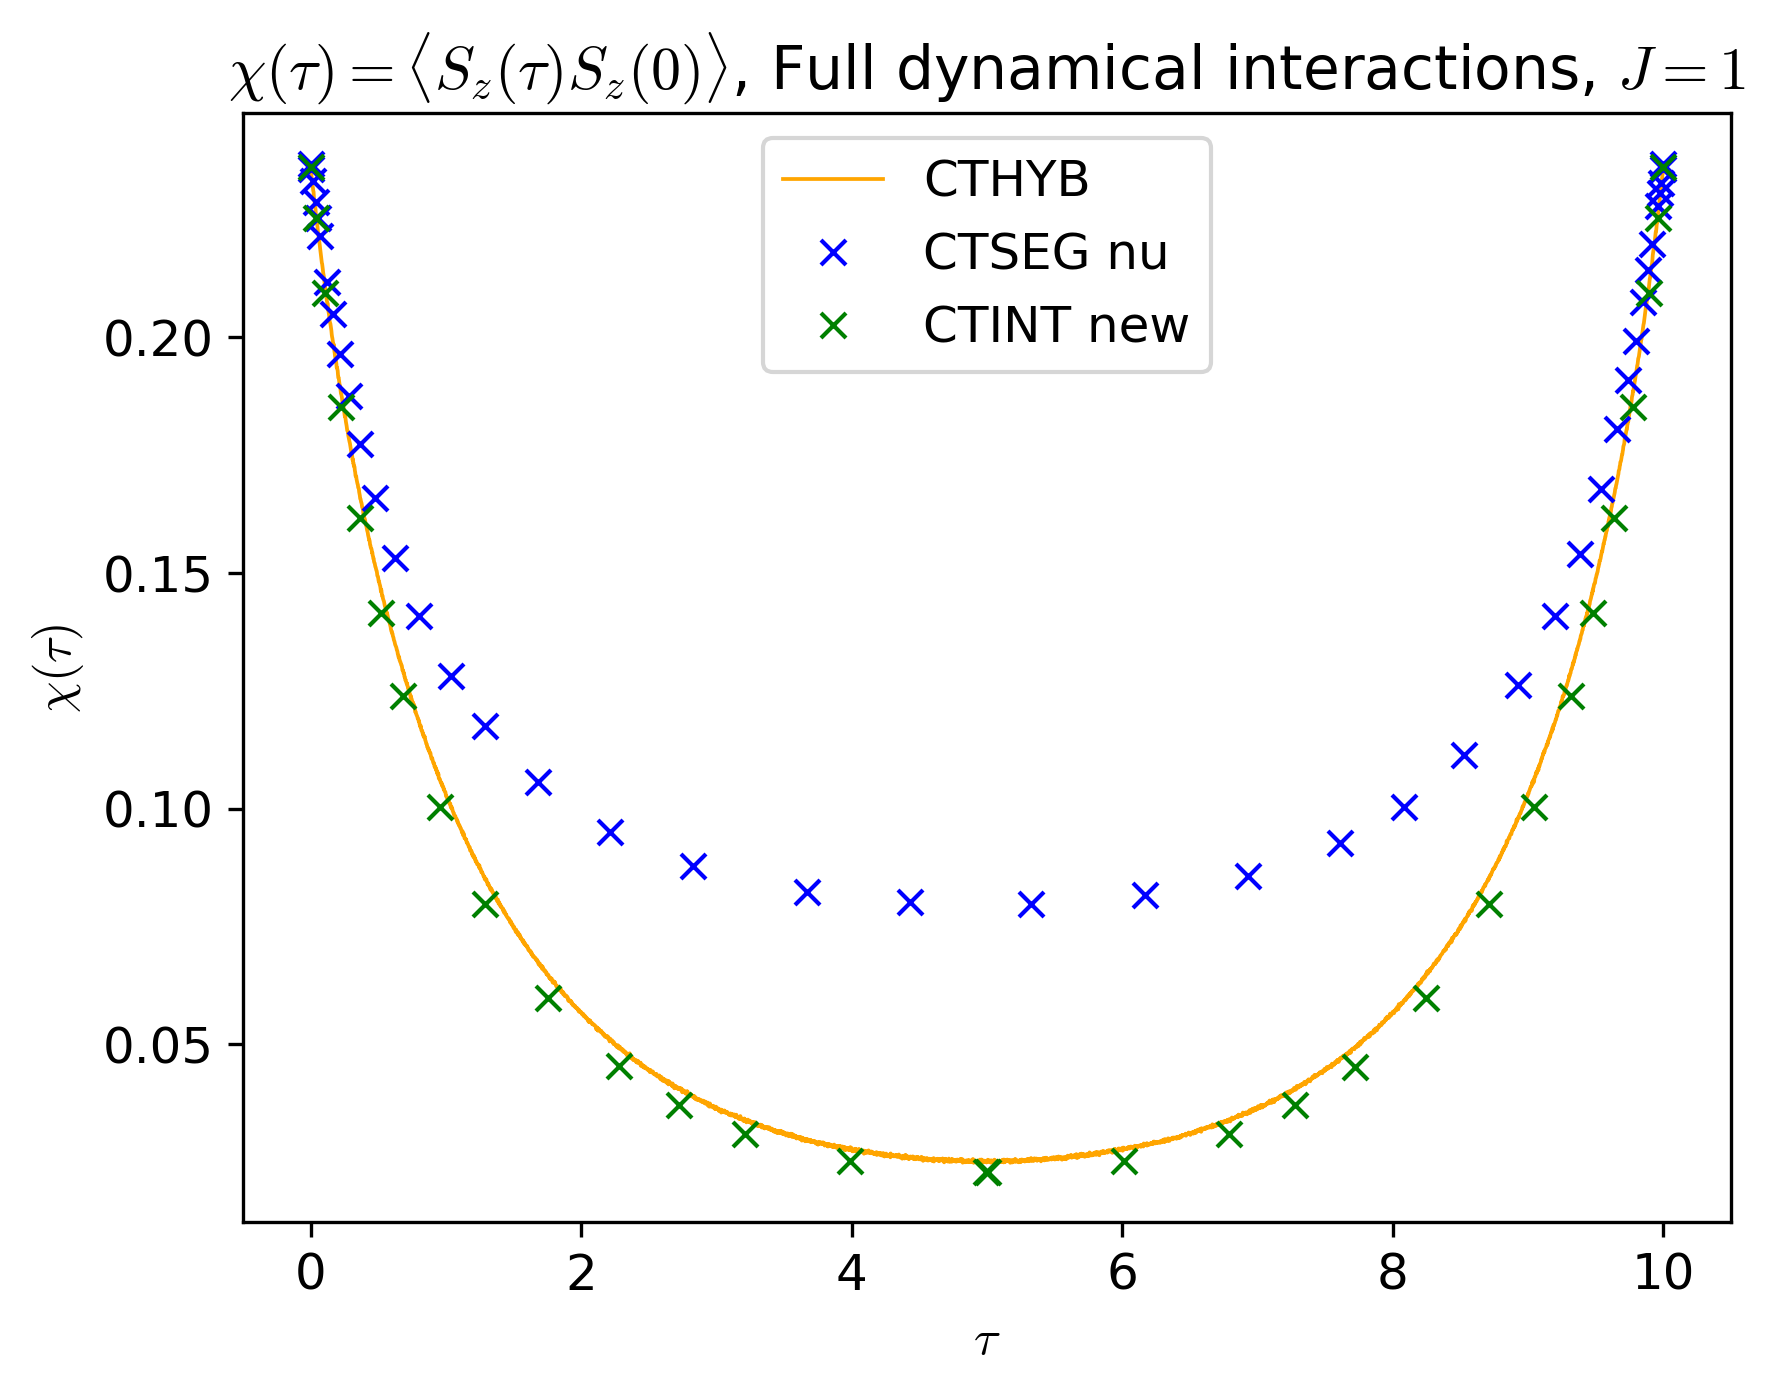

In [33]:
Sz_ctseg = 0.25*(nn["up", "up"   ] - nn["up", "down"] - nn["down", "up"] +nn["down", "down"])
Sz_nu = 0.25*(nn_nu["up", "up" ] - nn_nu["up", "down"] - nn_nu["down", "up"] +nn_nu["down", "down"])
Sz_ctint = SzSz_int_tau#1.0*(nn_ctint["up", "up" ] - nn_ctint["up", "dn"] - nn_ctint["dn", "up"] +nn_ctint["dn", "dn"])
Sz_ctint_dlr = make_gf_dlr(Sz_ctint)
Sz_ctint = make_gf_dlr_imtime(Sz_ctint_dlr)
oplot(Sz.real, color="orange", linewidth = 0.9, label="CTHYB")
#oplot(Sz_ctseg.real, color="black", linewidth = 0.9, label="CTSEG")
oplot(Sz_nu.real, color="blue", linewidth = 0.9, label="CTSEG nu")
oplot(Sz_ctint.real, color="green", linewidth = 0.9, label="CTINT new")
plt.title(r"$\chi(\tau) =\langle S_z(\tau) S_z(0) \rangle$, Full dynamical interactions, $J = 1$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend()
plt.show()

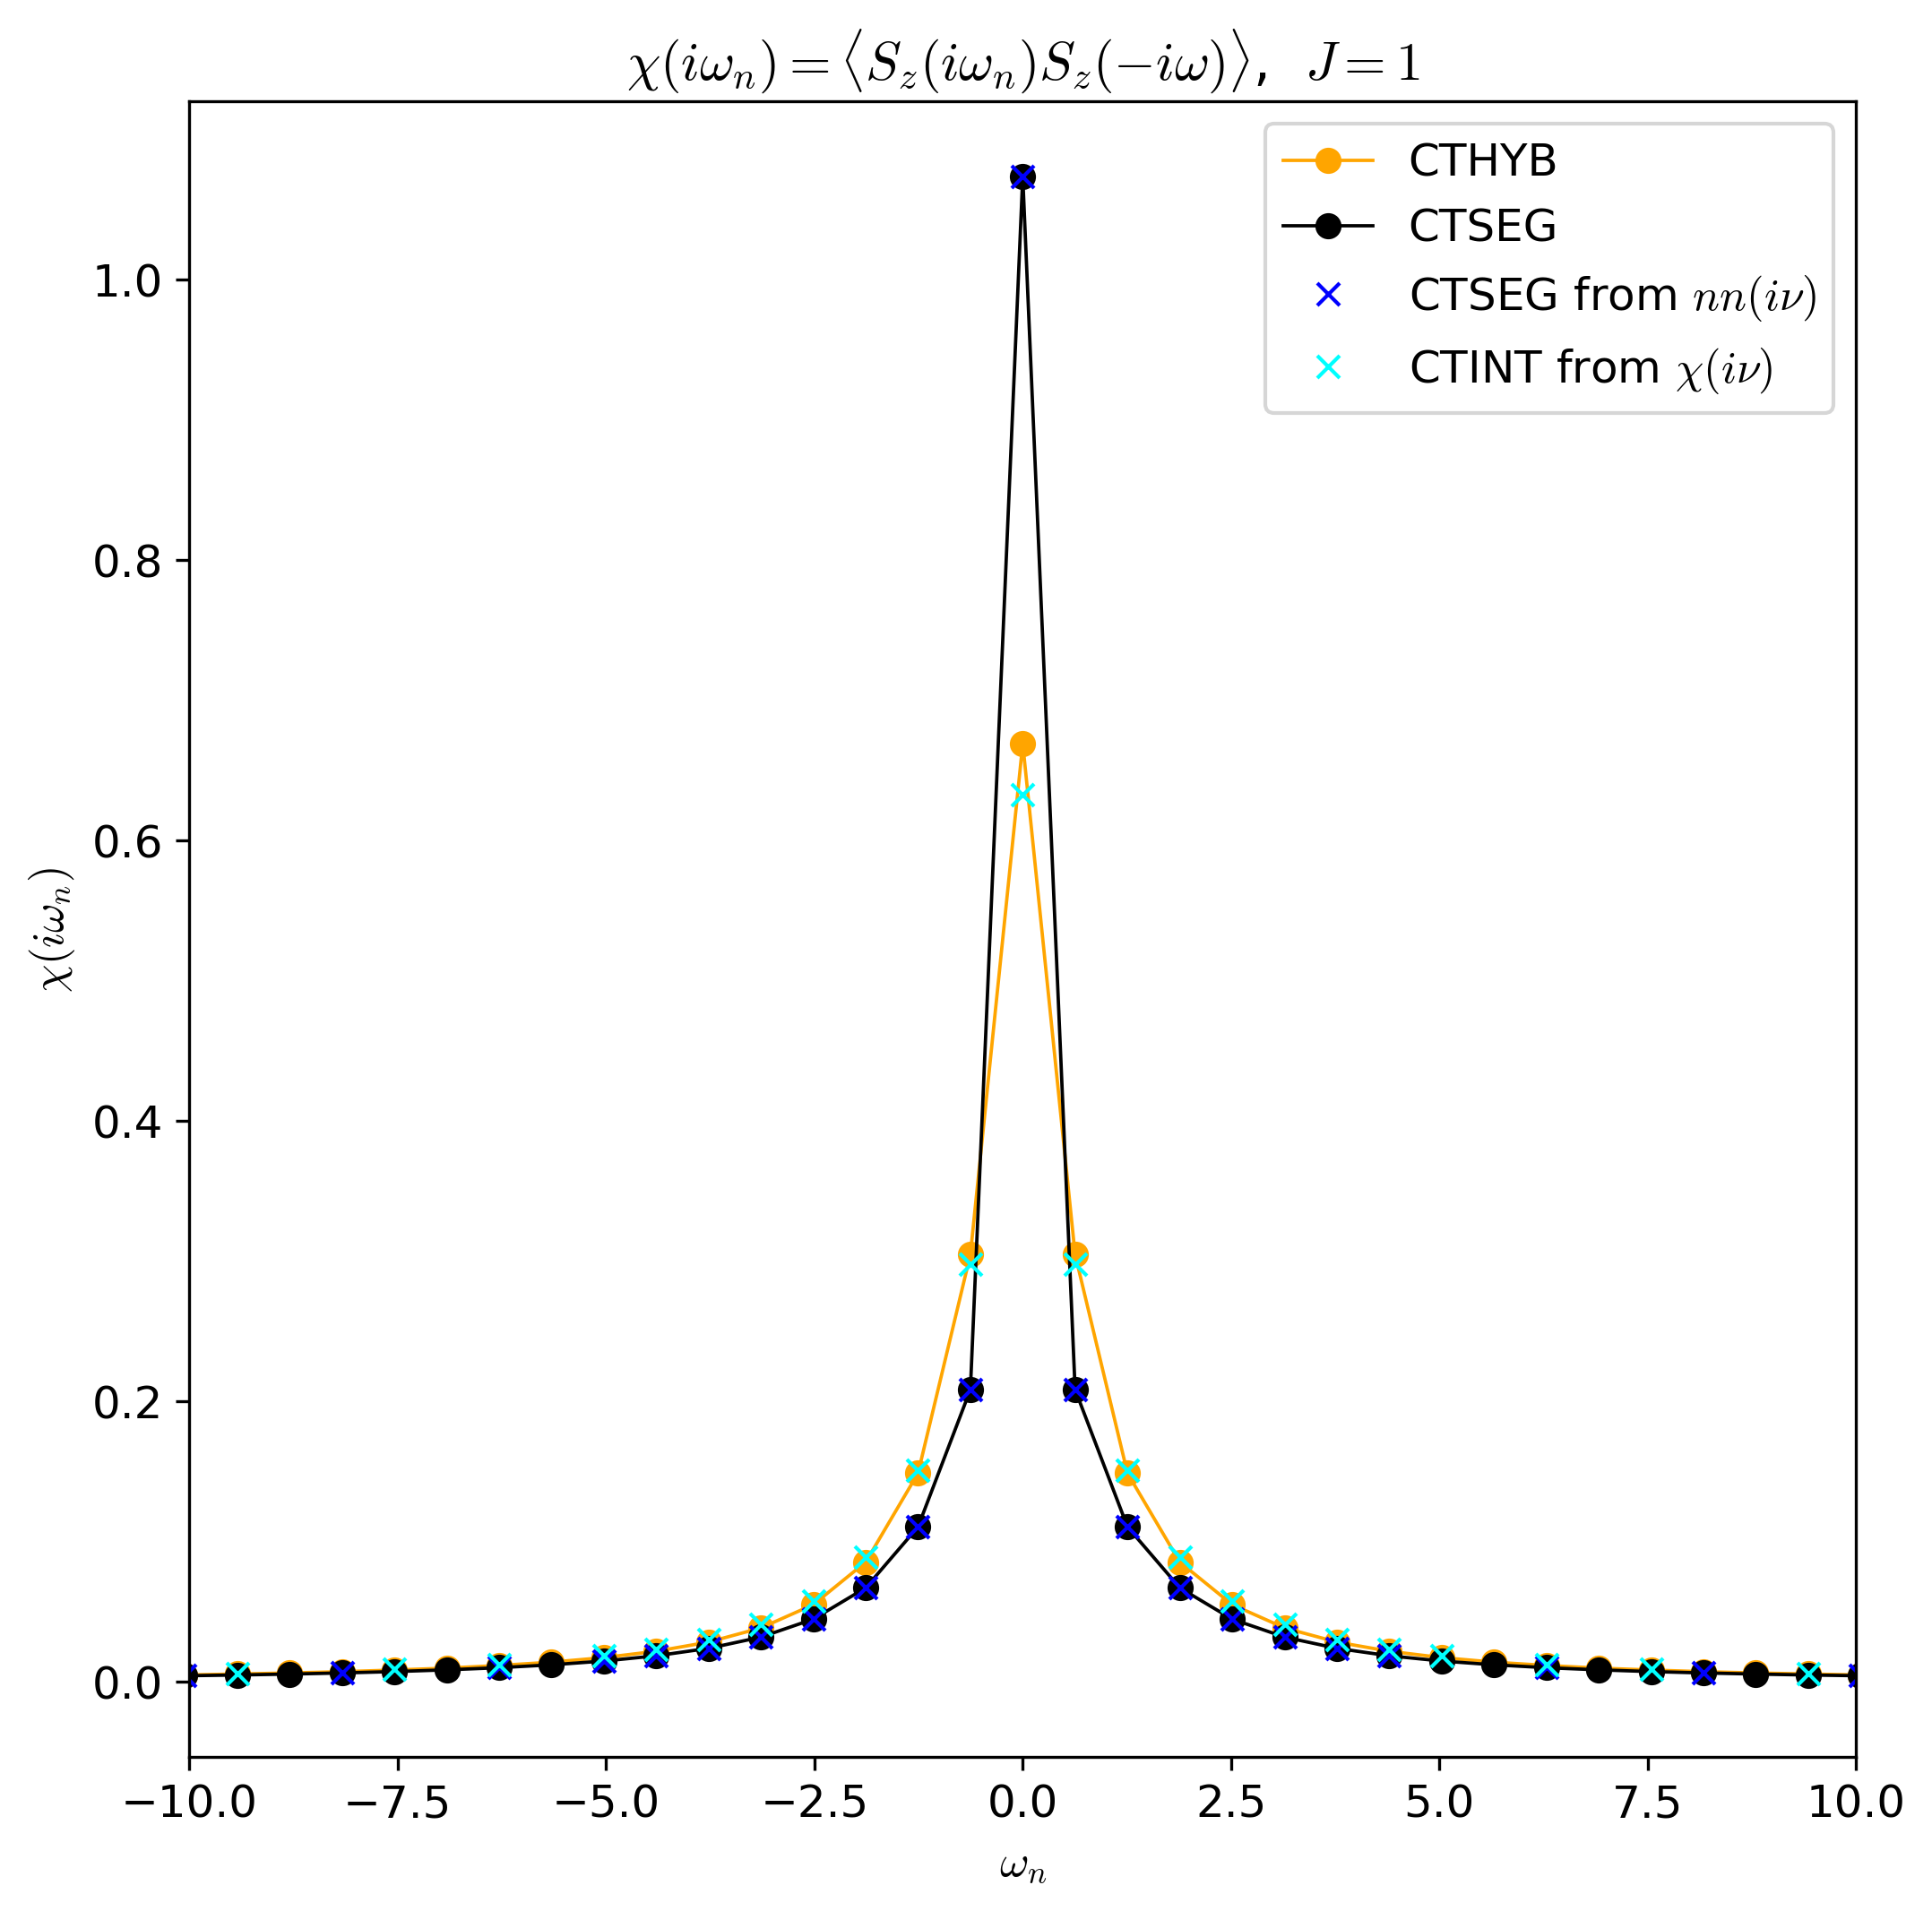

In [34]:
Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_cthyb_fourier = make_gf_from_fourier(Sz)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_nu)
Sz_ctint_fourier = make_gf_dlr_imfreq(Sz_ctint)

plt.figure(figsize=(8,8))
plt.xlim(-10,10)
oplot(Sz_cthyb_fourier.real, "-o",color="orange",  linewidth = 0.9, label="CTHYB")
oplot(Sz_ctseg_fourier.real, "-o",color="black",  linewidth = 0.9, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-o",color="blue",  linewidth = 0.9, label="CTSEG from $nn(i\\nu)$")
oplot(Sz_ctint_fourier.real, "-o",color="cyan",  linewidth = 0.9, label="CTINT from $\\chi(i\\nu)$")
plt.title(r"$\chi(i\omega_n) =\langle S_z(i\omega_n) S_z(-i\omega) \rangle$,  $J = 1$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend()
plt.show()

### Convergence of $\chi(i\omega_n) = \langle S_z(i\omega_n) S_z(-i\omega_n) \rangle$ with number of cycles, $J = 0.25$, full dynamical interactions

nw=100K: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.824803125


/home/andrewhardy/Documents/CCQ/unstable/installation/lib/python3.12/site-packages/triqs/plot/mpl_interface.py:110: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-s" (-> linestyle='-'). The keyword argument will take precedence.
  plt_fct(X, Y, *opt_list, **curve_dict)
/home/andrewhardy/Documents/CCQ/unstable/installation/lib/python3.12/site-packages/triqs/plot/mpl_interface.py:110: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-s" (-> marker='s'). The keyword argument will take precedence.
  plt_fct(X, Y, *opt_list, **curve_dict)


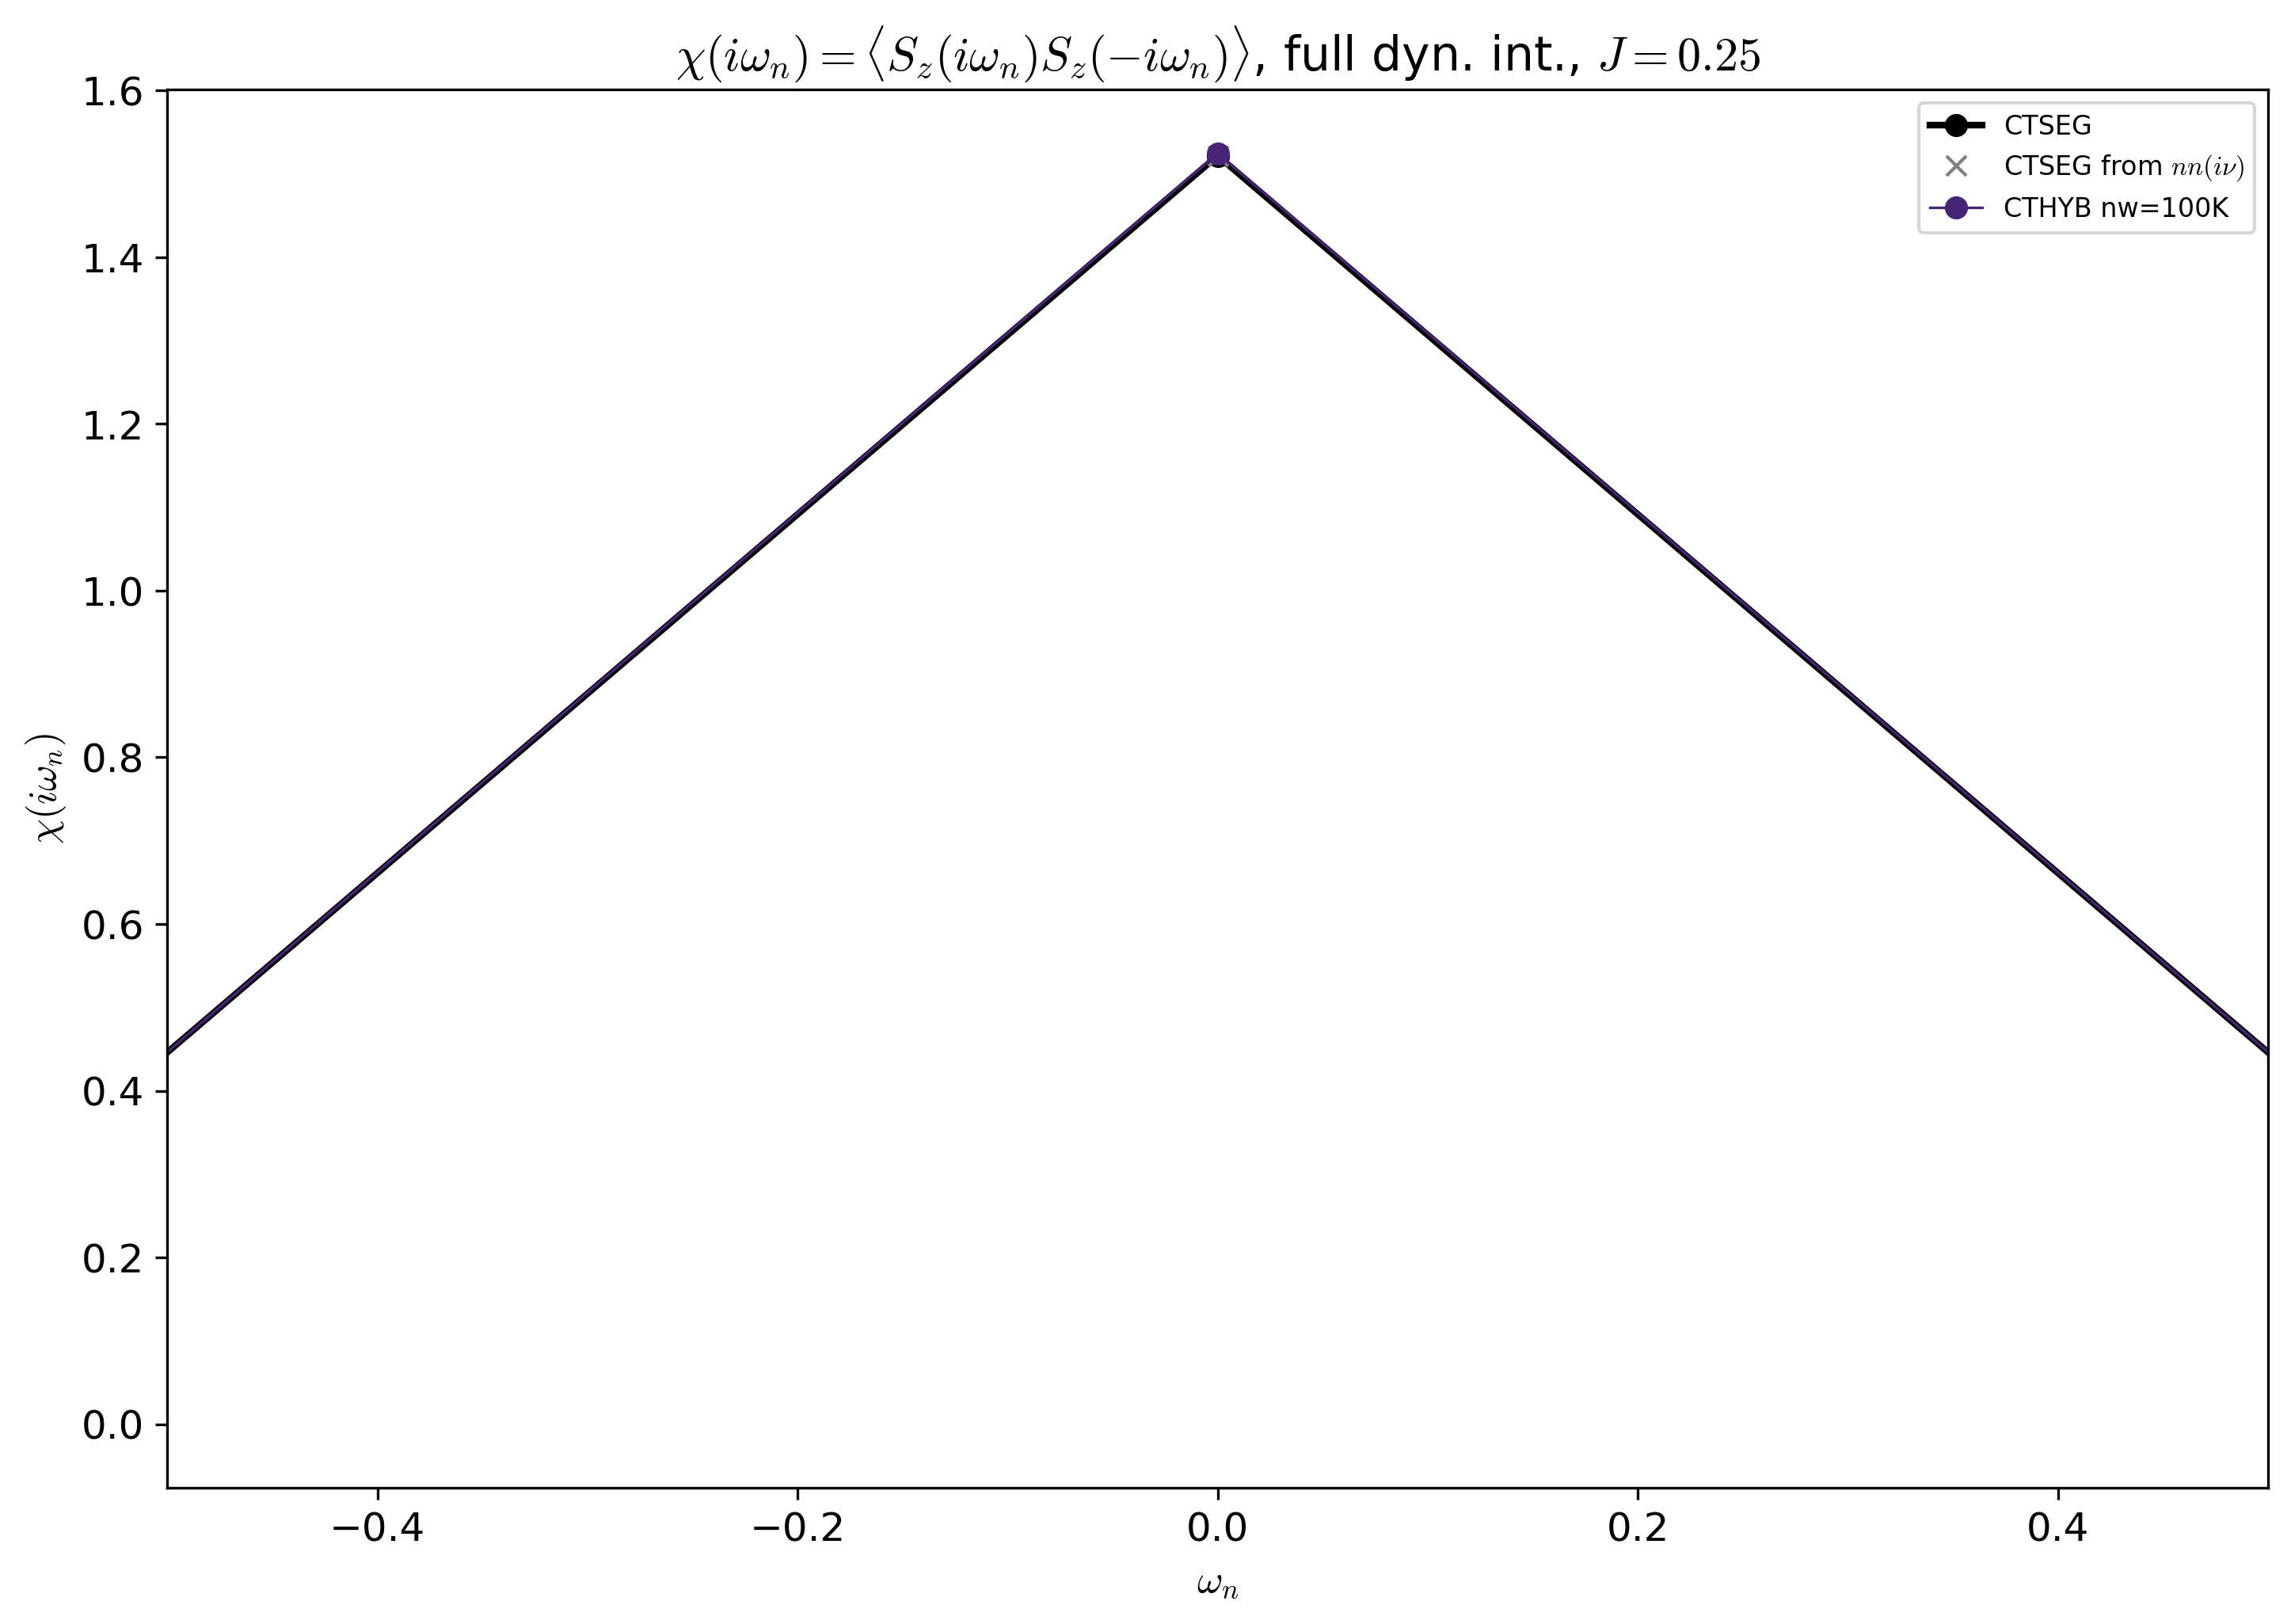

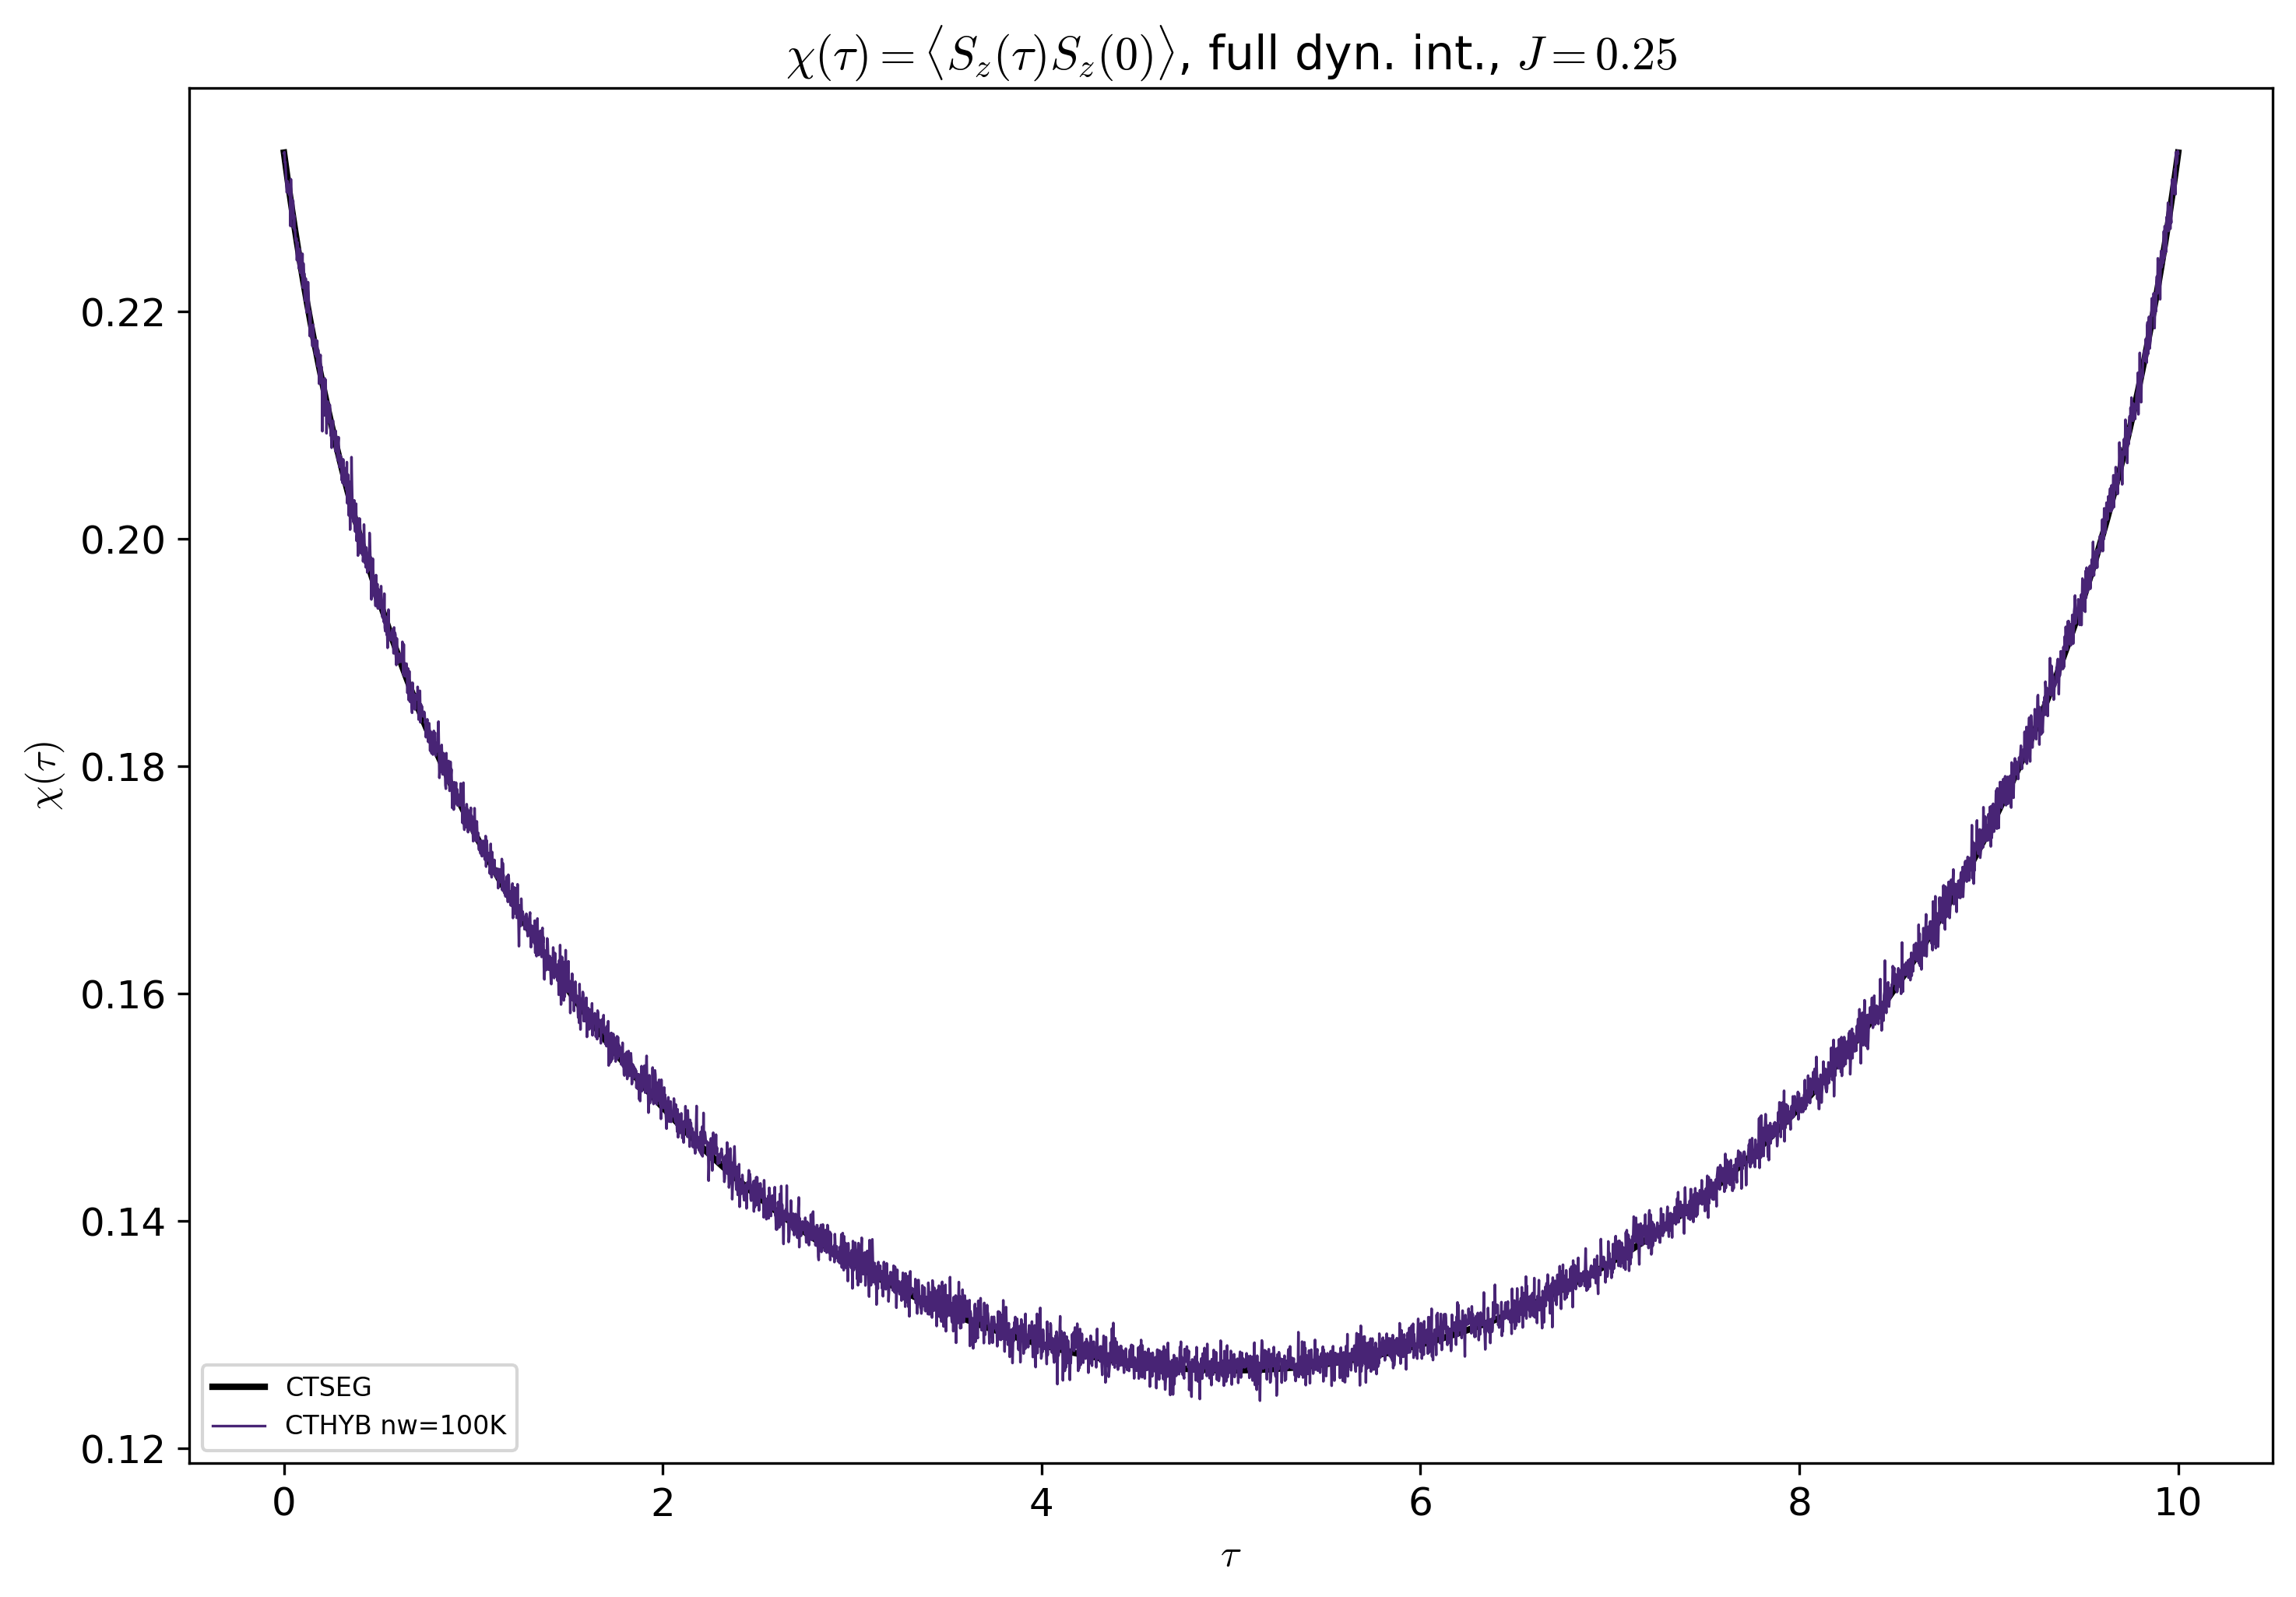

In [35]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"

# CTSEG reference
with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    nn_ref = A["nn_tau"]
    nn_iw_ref = A["nn_nu"]
    nn_nu_ref = make_gf_dlr_imtime(nn_iw_ref)

Sz_ctseg = 0.25*(nn_ref["up","up"] - nn_ref["up","down"] - nn_ref["down","up"] + nn_ref["down","down"])
Sz_ctseg_nu = 0.25*(nn_nu_ref["up","up"] - nn_nu_ref["up","down"] - nn_nu_ref["down","up"] + nn_nu_ref["down","down"])

# CTHYB files sorted by number of cycles
cthyb_files = [
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000_mins-50.h5",       "1K"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000_mins-50.h5",      "10K"),
    ("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000_mins-50.h5",    "100K"),
   #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000000_mins-50.h5",     "1M"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000000_mins-50.h5",   "10M"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-20000000_mins-50.h5",   "20M"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-50000000_mins-50.h5",   "50M"),
    #("spin_spin_cthyb_J-0.25-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000000_mins-50.h5", "100M"),
]

Sz_hyb = {}
for fname, label in cthyb_files:
    with HDFArchive(f"{data_loc}/{fname}", "r") as A:
        print(f"nw={label}: keys={A.keys()}, avg_sign={A['average_sign']}")
        Sz_hyb[label] = A["O_tau"]

# --- Frequency domain plot ---
plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(cthyb_files)))

Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_ctseg_nu)
oplot(Sz_ctseg_fourier.real, "-o", color="black", linewidth=2.0, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-s", color="gray", linewidth=1.5, label=r"CTSEG from $nn(i\nu)$")

for (label, Sz), color in zip(Sz_hyb.items(), colors):
    Sz_fourier = make_gf_from_fourier(Sz)
    oplot(Sz_fourier.real, "-o", color=color, linewidth=0.8, label=f"CTHYB nw={label}")

plt.xlim(-10, 10)
plt.title(r"$\chi(i\omega_n) = \langle S_z(i\omega_n) S_z(-i\omega_n) \rangle$, full dyn. int., $J = 0.25$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.xlim(-0.5,0.5)

plt.show()

# --- Tau domain plot ---
plt.figure(figsize=(10, 7))
oplot(Sz_ctseg.real, color="black", linewidth=2.0, label="CTSEG")

for (label, Sz), color in zip(Sz_hyb.items(), colors):
    oplot(Sz.real, color=color, linewidth=0.8, label=f"CTHYB nw={label}")

plt.title(r"$\chi(\tau) = \langle S_z(\tau) S_z(0) \rangle$, full dyn. int., $J = 0.25$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

nw=100K: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.2991709375
nw=1M: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.299608
nw=20M: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.299528775
nw=50M: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.2995407675
nw=100M: keys=['G_tau', 'O_tau', 'average_sign', 'perturbation_order'], avg_sign=0.29952690233333334


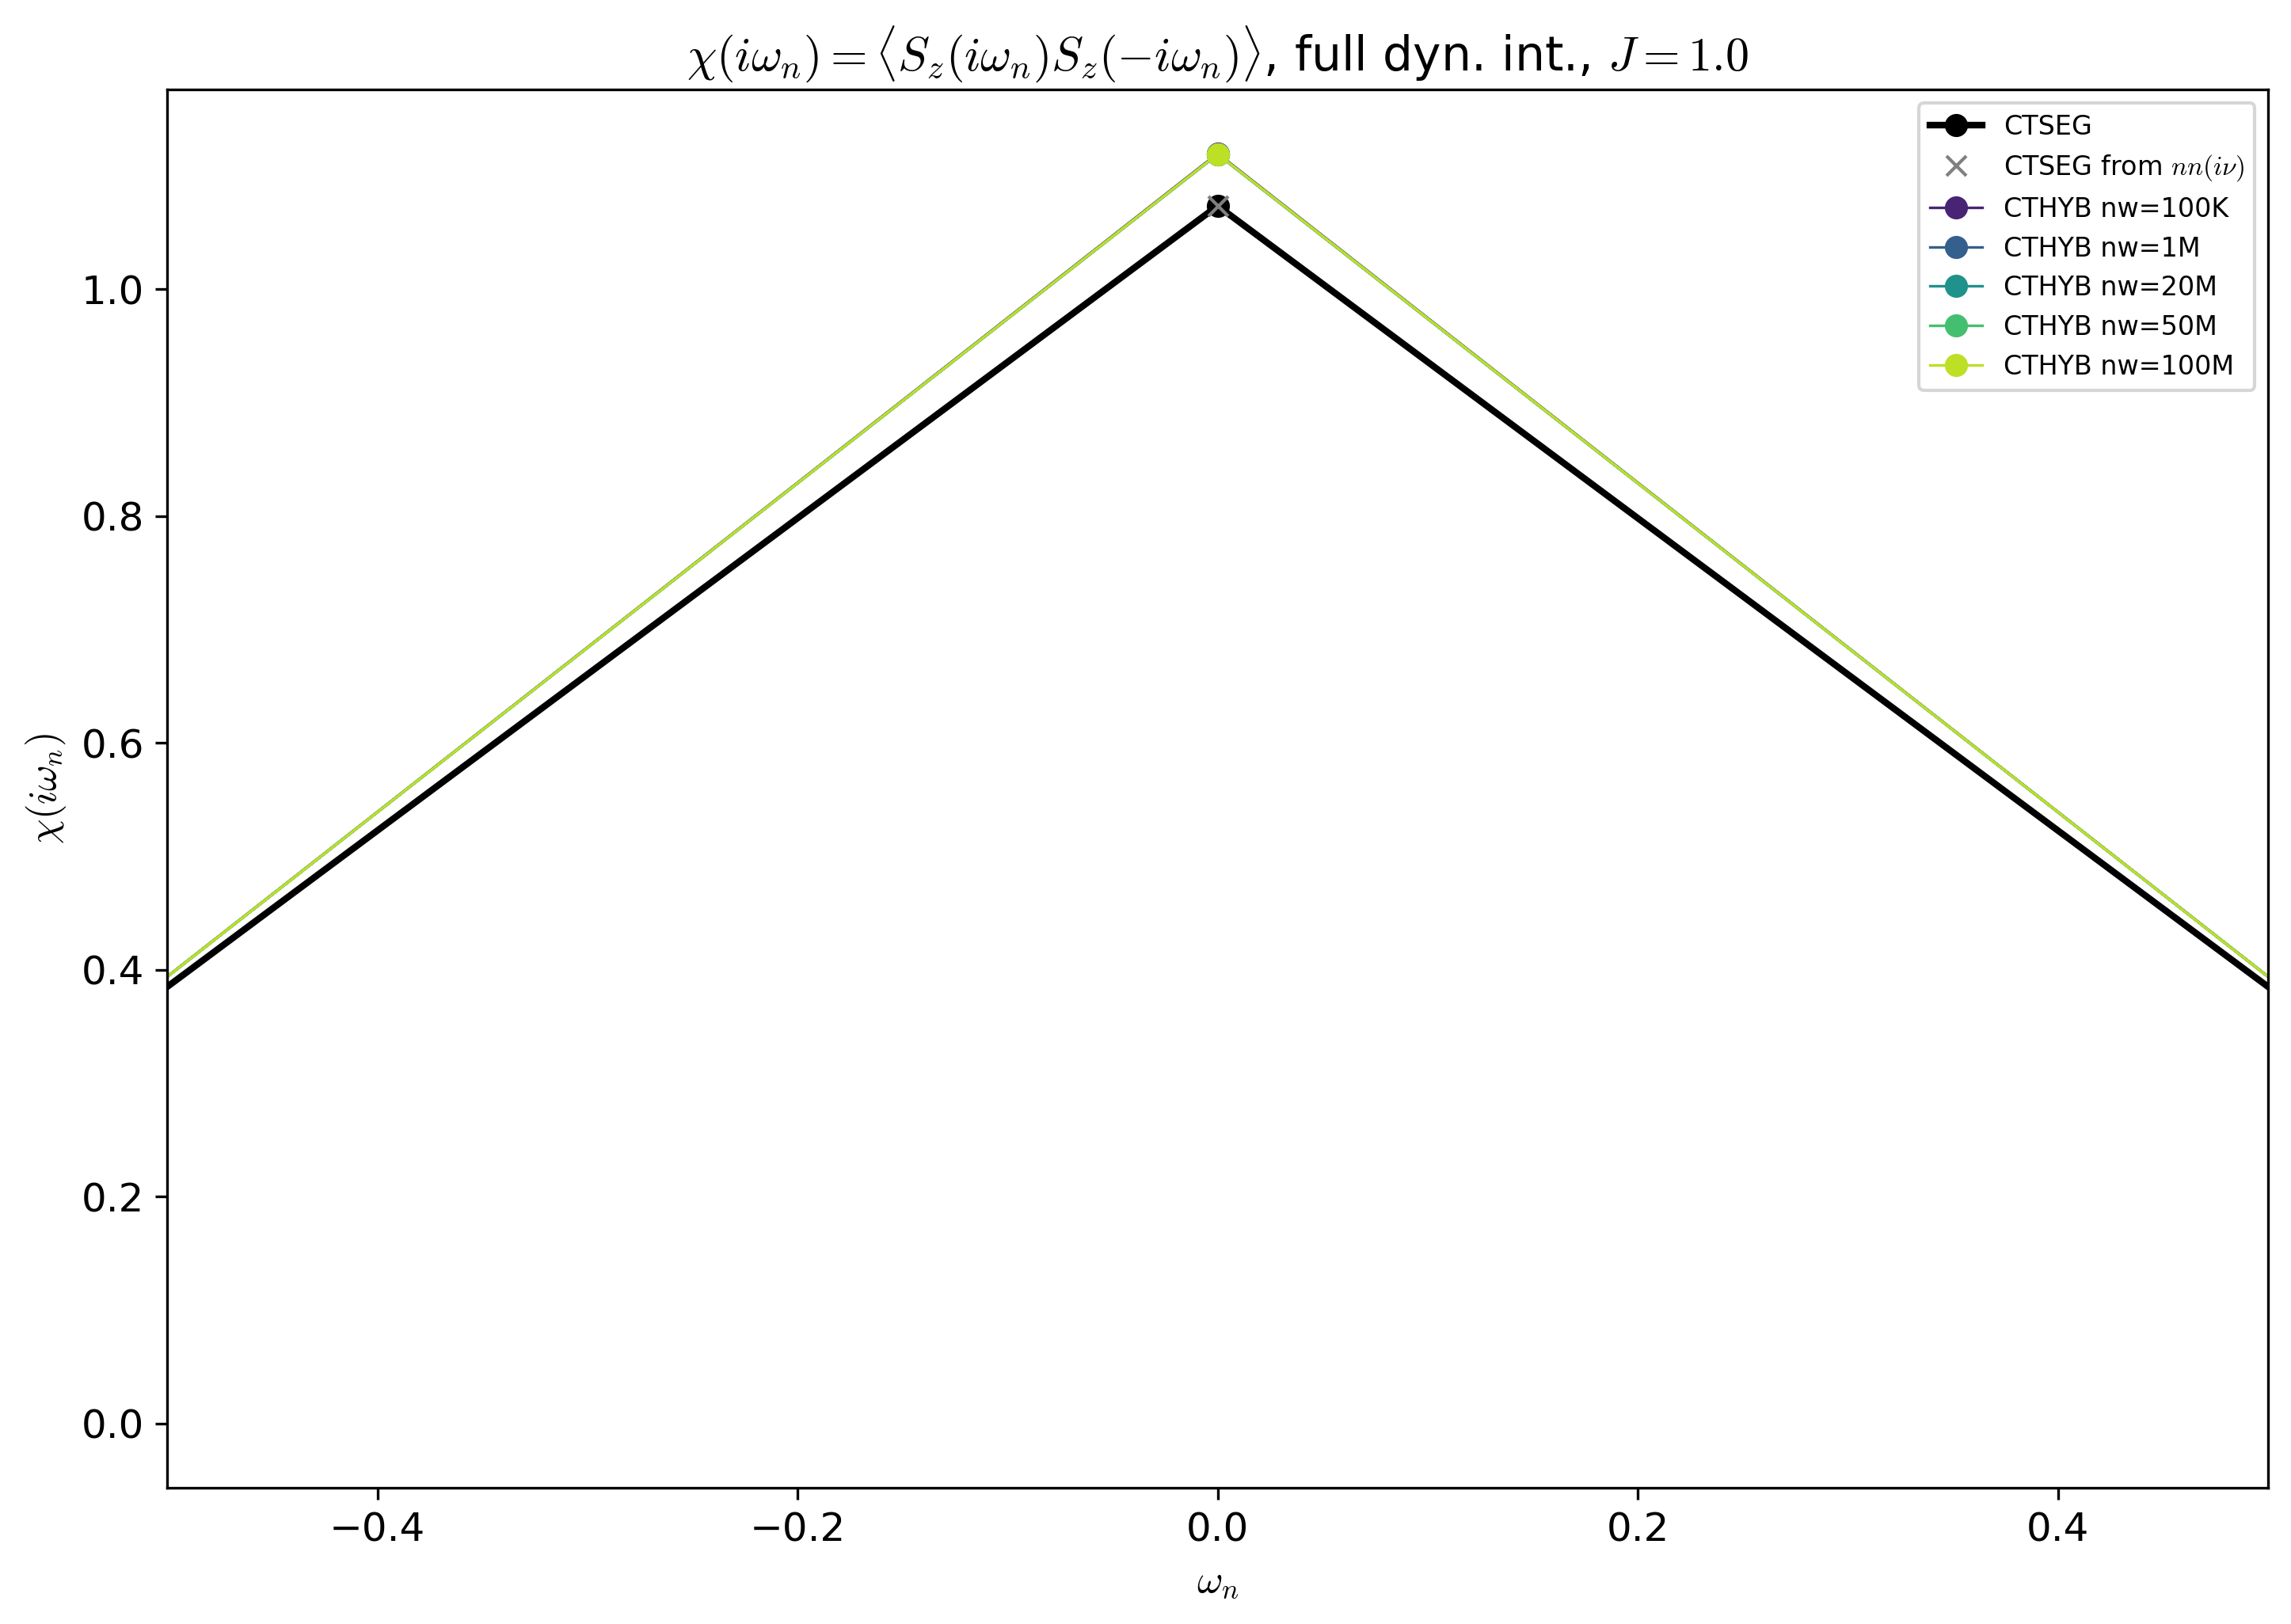

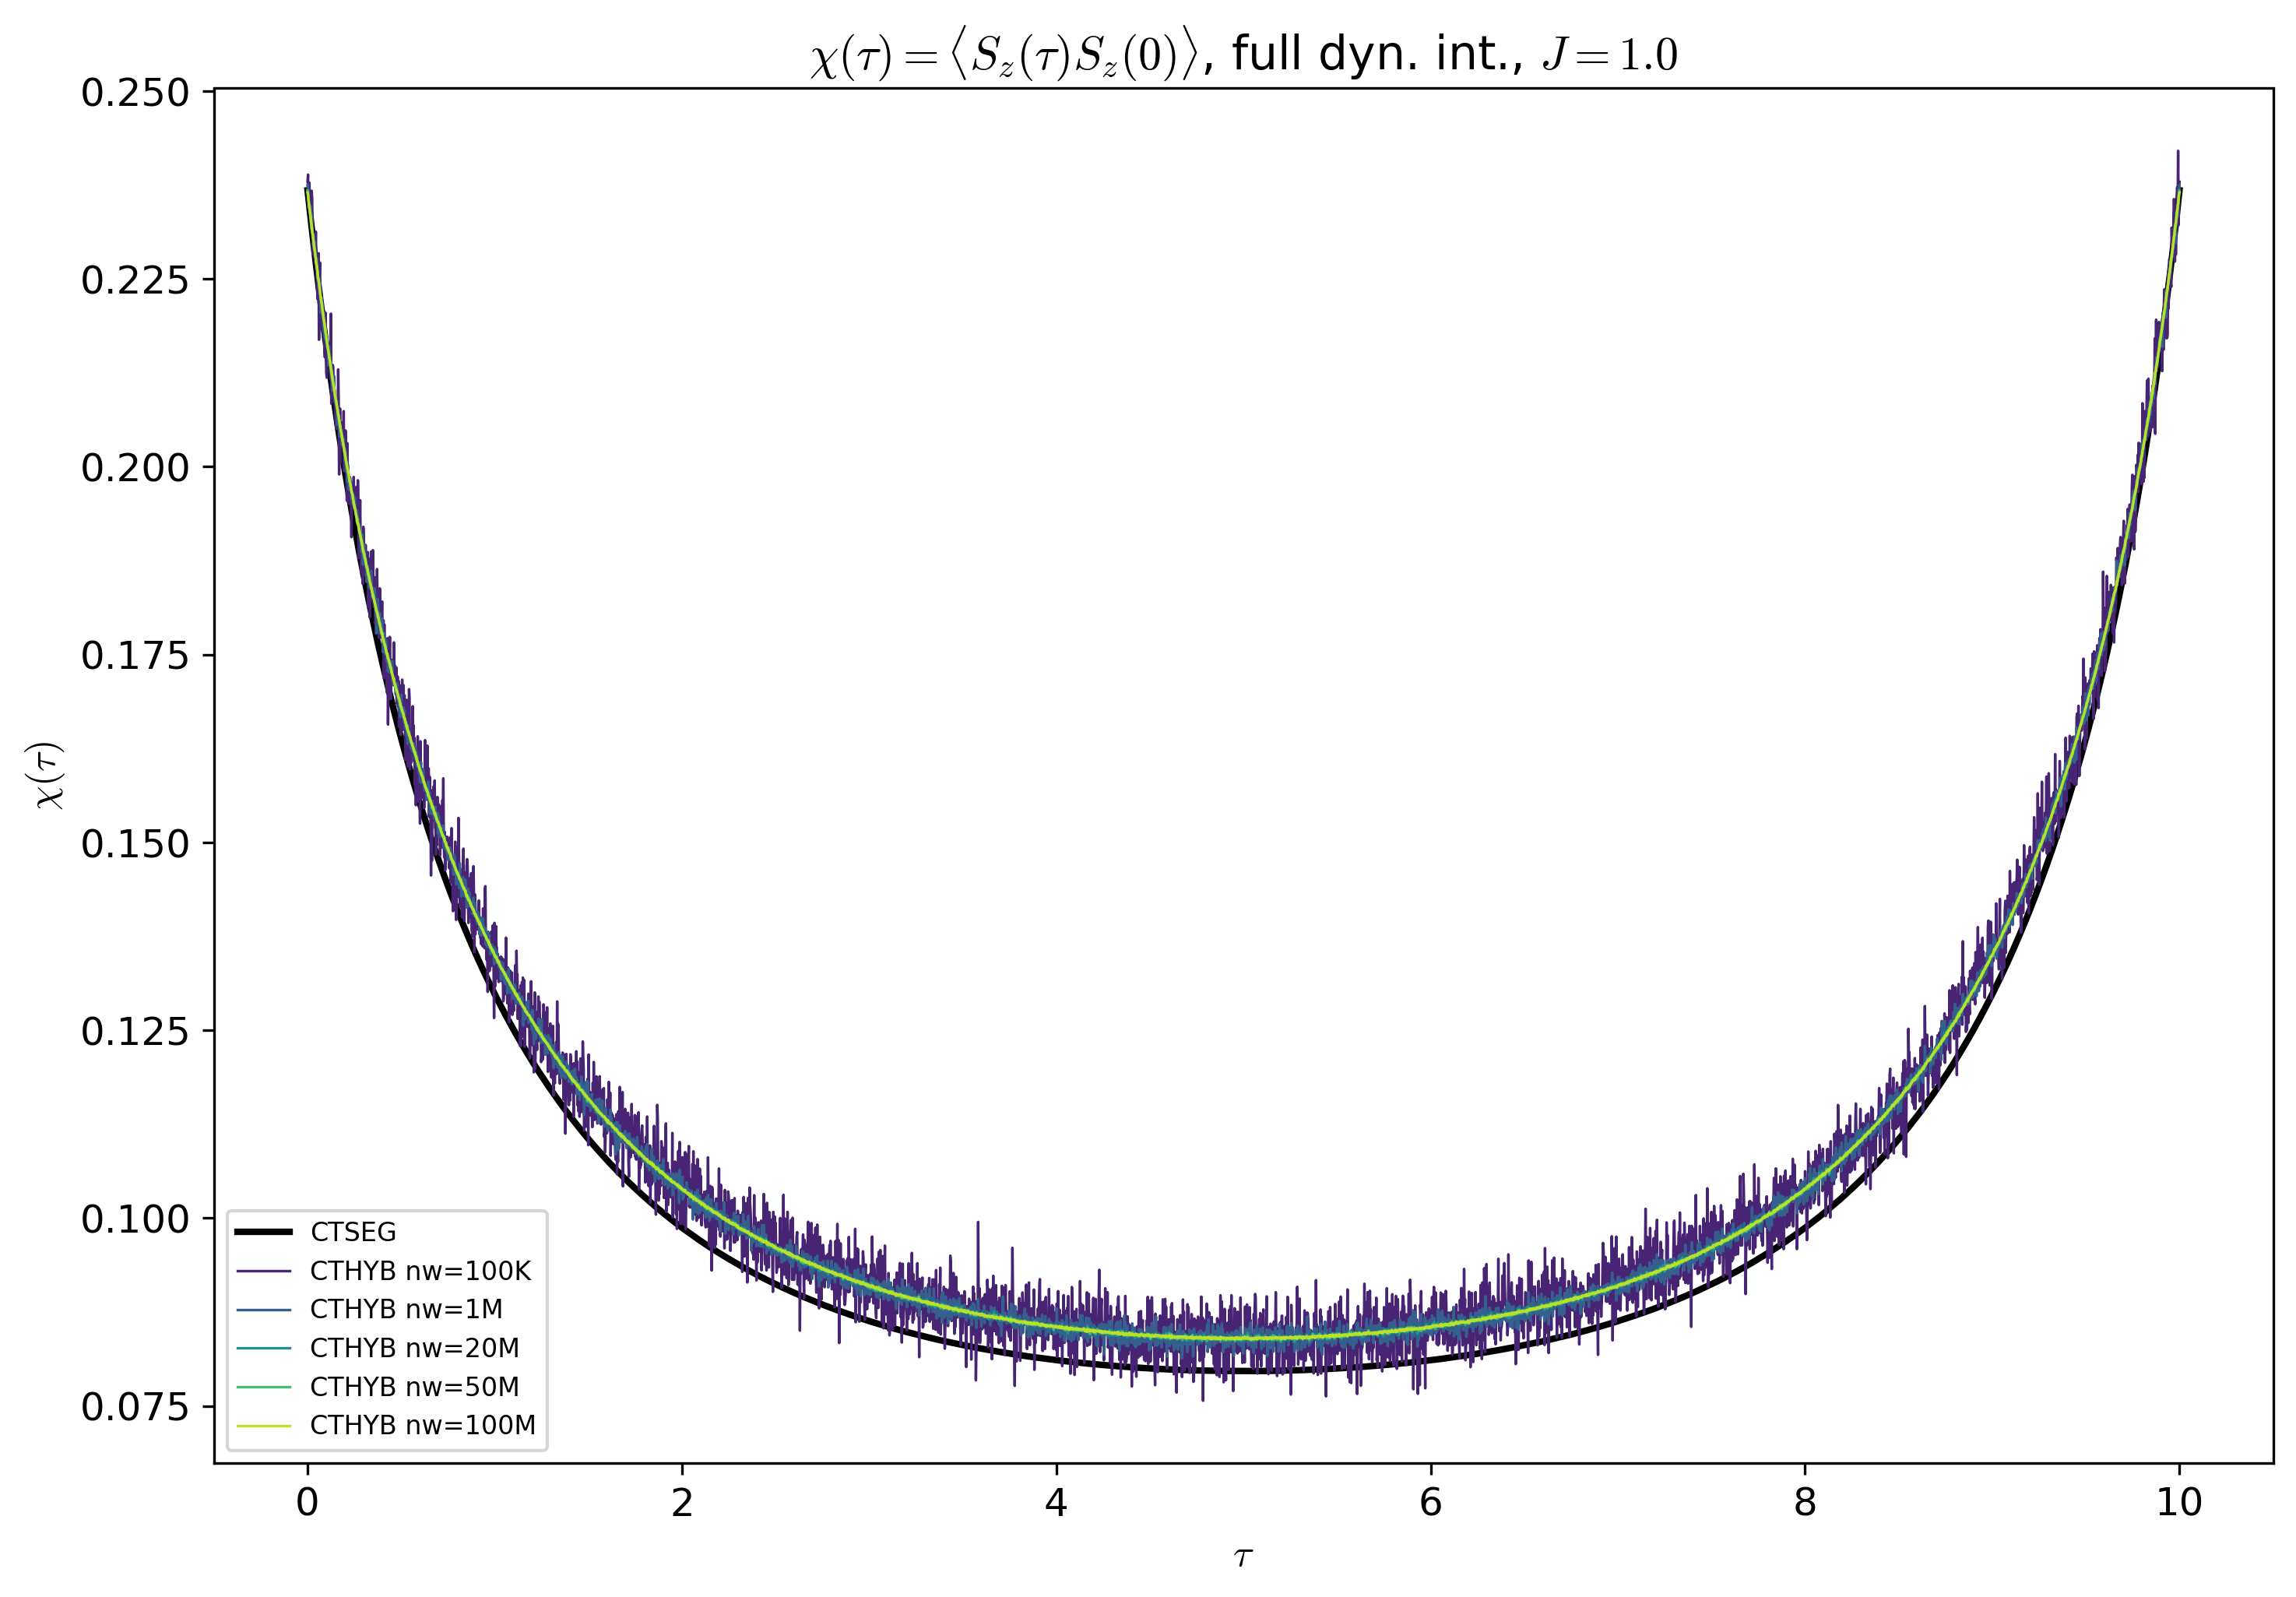

In [36]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"

# CTSEG reference
with HDFArchive(f"{data_loc}/spin_spin_ctseg_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0.h5", "r") as A:
    nn_ref = A["nn_tau"]
    nn_iw_ref = A["nn_nu"]
    nn_nu_ref = make_gf_dlr_imtime(nn_iw_ref)

Sz_ctseg = 0.25*(nn_ref["up","up"] - nn_ref["up","down"] - nn_ref["down","up"] + nn_ref["down","down"])
Sz_ctseg_nu = 0.25*(nn_nu_ref["up","up"] - nn_nu_ref["up","down"] - nn_nu_ref["down","up"] + nn_nu_ref["down","down"])

# CTHYB files sorted by number of cycles
cthyb_files = [
    #("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000_mins-50.h5",       "1K"),
    #("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000_mins-50.h5",      "10K"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000_mins-50.h5",    "100K"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-1000000_mins-50.h5",     "1M"),
    #("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-10000000_mins-50.h5",   "10M"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-20000000_mins-50.h5",   "20M"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-50000000_mins-50.h5",   "50M"),
    ("spin_spin_cthyb_J-1.0-U-4.0_1.0_1.0_1.0_1.0_1.0_b-10.0_nw-100000000_mins-50.h5", "100M"),
]

Sz_hyb = {}
for fname, label in cthyb_files:
    with HDFArchive(f"{data_loc}/{fname}", "r") as A:
        print(f"nw={label}: keys={A.keys()}, avg_sign={A['average_sign']}")
        Sz_hyb[label] = A["O_tau"]

# --- Frequency domain plot ---
plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(cthyb_files)))

Sz_ctseg_fourier = make_gf_from_fourier(Sz_ctseg)
Sz_ctseg_nu_fourier = make_gf_dlr_imfreq(Sz_ctseg_nu)
oplot(Sz_ctseg_fourier.real, "-o", color="black", linewidth=2.0, label="CTSEG")
oplot(Sz_ctseg_nu_fourier.real, "-s", color="gray", linewidth=1.5, label=r"CTSEG from $nn(i\nu)$")

for (label, Sz), color in zip(Sz_hyb.items(), colors):
    Sz_fourier = make_gf_from_fourier(Sz)
    oplot(Sz_fourier.real, "-o", color=color, linewidth=0.8, label=f"CTHYB nw={label}")

plt.xlim(-10, 10)
plt.title(r"$\chi(i\omega_n) = \langle S_z(i\omega_n) S_z(-i\omega_n) \rangle$, full dyn. int., $J = 1.0$")
plt.ylabel(r"$\chi(i\omega_n)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.xlim(-0.5,0.5)

plt.show()

# --- Tau domain plot ---
plt.figure(figsize=(10, 7))
oplot(Sz_ctseg.real, color="black", linewidth=2.0, label="CTSEG")

for (label, Sz), color in zip(Sz_hyb.items(), colors):
    oplot(Sz.real, color=color, linewidth=0.8, label=f"CTHYB nw={label}")

plt.title(r"$\chi(\tau) = \langle S_z(\tau) S_z(0) \rangle$, full dyn. int., $J = 1.0$")
plt.ylabel(r"$\chi(\tau)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()